### Я сделал часть анализа уже в HW4, но во избежании путанницы продублировал здесь часть EDA из HW4

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('Set2')

PARQUET_PATH = 'm5_dataset_final.parquet'  # файл рядом с ноутбуком
SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_parquet(PARQUET_PATH)
cat_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
            'weekday', 'event_name_1', 'event_type_1', 'event_name_2']
for col in cat_cols:
    df[col] = df[col].astype('category')

print(f'Shape: {df.shape}')
print(f'Колонки: {list(df.columns)}')
df.head(3)

Shape: (33202011, 46)
Колонки: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'is_weekend', 'week_of_year', 'day_of_year', 'has_event', 'is_top_event', 'price_roll_mean_28', 'price_rel', 'is_promo', 'price_change', 'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_28', 'lag_56', 'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28', 'roll_mean_56', 'roll_std_56', 'd_num', 'age_of_series', 'is_new_sku', 'is_outlier_day', 'split']


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,weekday,...,roll_std_7,roll_mean_28,roll_std_28,roll_mean_56,roll_std_56,d_num,age_of_series,is_new_sku,is_outlier_day,split
0,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_1,3,2011-01-29,Saturday,...,0.00000,-1.0,0.00000,-1.0,0.00000,0,0,1,0,train
1,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,Sunday,...,0.00000,3.0,0.00000,3.0,0.00000,1,1,1,0,train
2,FOODS_1_001_CA_1_evaluation,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,Monday,...,2.12132,1.5,2.12132,1.5,2.12132,2,2,1,0,train


In [3]:
train = df[df['split'] == 'train']
val1  = df[df['split'] == 'val1']
val2  = df[df['split'] == 'val2']

print('Сплиты')
print(df['split'].value_counts().to_frame('строк'))

print('\nВременной горизонт')
print(f'train: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'val1:  {val1["date"].min().date()} → {val1["date"].max().date()}')
print(f'val2:  {val2["date"].min().date()} → {val2["date"].max().date()}')

print('\nОтрицательные продаж')
print(f'Строк с sales < 0: {(df["sales"] < 0).sum()}')

print('\n')
sentinel_cols = ['roll_mean_28', 'roll_mean_56', 'roll_std_28', 'roll_std_56']
for col in sentinel_cols:
    n = (df[col] == -1.0).sum()
    print(f'  {col}: {n:,} строк ({n/len(df):.1%})')

print('\nПропуски')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'NaN-пропусков нет')

Сплиты
          строк
split          
train  32427867
val2     388242
val1     385902

Временной горизонт
train: 2011-01-29 → 2016-03-27
val1:  2016-03-28 → 2016-04-24
val2:  2016-04-25 → 2016-05-22

Отрицательные продаж
Строк с sales < 0: 0


  roll_mean_28: 30,490 строк (0.1%)
  roll_mean_56: 30,490 строк (0.1%)
  roll_std_28: 0 строк (0.0%)
  roll_std_56: 0 строк (0.0%)

Пропуски
NaN-пропусков нет


## Качество данных

- Отрицательных продаж нет
- NaN-пропусков нет
- Sentinel -1.0 в roll_mean_28/56: ровно 30 490 строк = первый день каждого SKU,
  заменяем на lag_1 перед обучением
- Temporal split корректный: train → val1 → val2 без пересечений

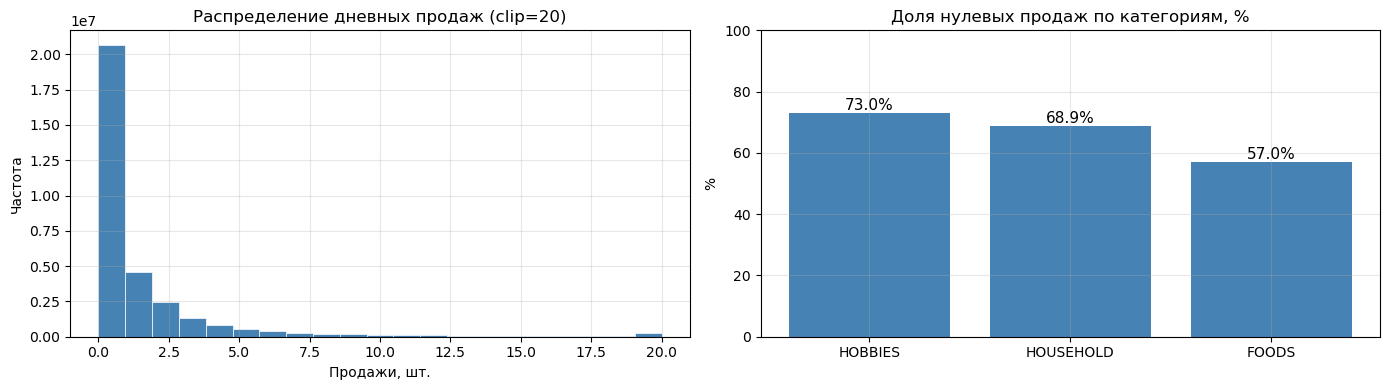

Медиана:       0 шт./день
Среднее:       1.42 шт./день
p95:           6 шт./день
max:           763 шт./день
Доля нулей:    63.7%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма (clip для читаемости хвоста)
axes[0].hist(train['sales'].clip(upper=20), bins=21,
             edgecolor='white', linewidth=0.5, color='steelblue')
axes[0].set_title('Распределение дневных продаж (clip=20)')
axes[0].set_xlabel('Продажи, шт.')
axes[0].set_ylabel('Частота')

# Доля нулей по категориям
zero_share = (
    train.groupby('cat_id', observed=True)['sales']
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
)
axes[1].bar(zero_share.index, zero_share.values, color='steelblue')
axes[1].set_title('Доля нулевых продаж по категориям, %')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
for i, v in enumerate(zero_share.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# Сводные цифры
print(f'Медиана:       {train["sales"].median():.0f} шт./день')
print(f'Среднее:       {train["sales"].mean():.2f} шт./день')
print(f'p95:           {train["sales"].quantile(0.95):.0f} шт./день')
print(f'max:           {train["sales"].max():.0f} шт./день')
print(f'Доля нулей:    {(train["sales"] == 0).mean():.1%}')

**Вывод:** спрос сильно правосторонний — медиана 0, среднее 1.42.
63.7% наблюдений — нули (intermittent demand).
Квантиль q=0.5 для большинства SKU = 0, что делает квантильное прогнозирование
особенно важным: q=0.1 и q=0.9 несут основную аналитическую ценность.

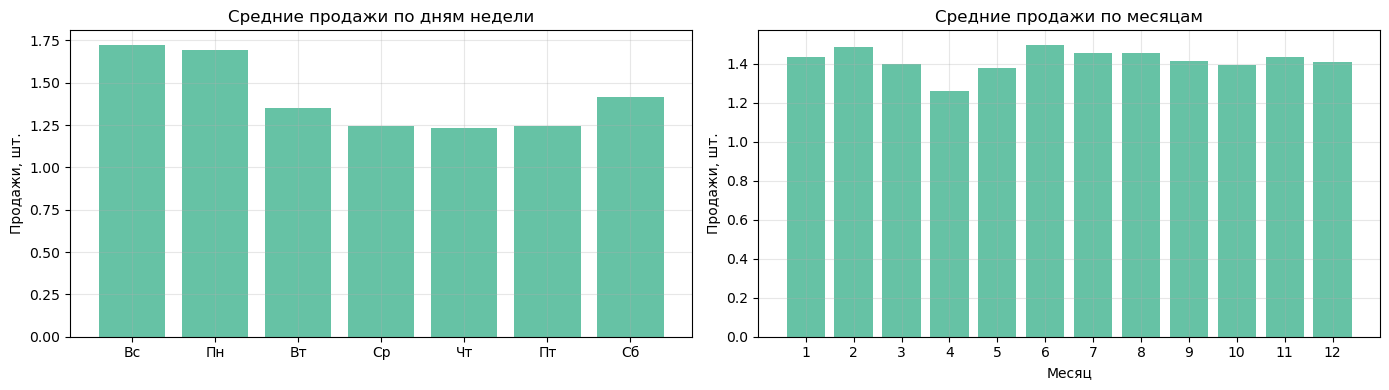

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Продажи по дням недели
wday_map = {1: 'Вс', 2: 'Пн', 3: 'Вт', 4: 'Ср', 5: 'Чт', 6: 'Пт', 7: 'Сб'}
wday_sales = (
    train.groupby('wday')['sales'].mean()
    .rename(index=wday_map)
)
axes[0].bar(wday_sales.index, wday_sales.values)
axes[0].set_title('Средние продажи по дням недели')
axes[0].set_ylabel('Продажи, шт.')

# Продажи по месяцам
month_sales = train.groupby('month')['sales'].mean()
axes[1].bar(month_sales.index, month_sales.values)
axes[1].set_title('Средние продажи по месяцам')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Продажи, шт.')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Вывод:** выраженная недельная сезонность (Вс/Пн vs Ср/Пт).
Месячная сезонность слабее — заметный провал в апреле-мае.
`wday` — обязательный признак для любой модели.

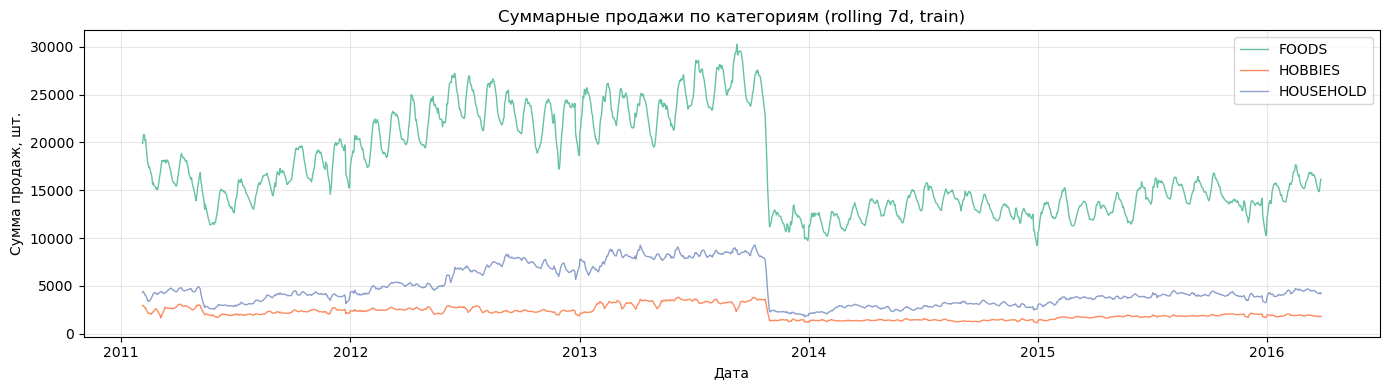

In [6]:
# Агрегируем по дате и категории (только train)
daily_cat = (
    train.groupby(['date', 'cat_id'], observed=True)['sales']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
for cat, grp in daily_cat.groupby('cat_id', observed=True):
    ax.plot(grp['date'], grp['sales'].rolling(7).mean(),
            label=cat, linewidth=1)

ax.set_title('Суммарные продажи по категориям (rolling 7d, train)')
ax.set_xlabel('Дата')
ax.set_ylabel('Сумма продаж, шт.')
ax.legend()
plt.tight_layout()
plt.show()

**Вывод:** виден структурный разрыв ~конец 2013 — резкое падение по всем категориям.
Вероятная причина: в датасете часть SKU появляется постепенно (44% товаров стартуют
не с d_1), и агрегат в начале завышен за счёт "ранних" SKU с длинной историей.
После разрыва уровень стабилизируется. `age_of_series` как признак это компенсирует.
FOODS доминирует по объёму, HOBBIES — наименьший.

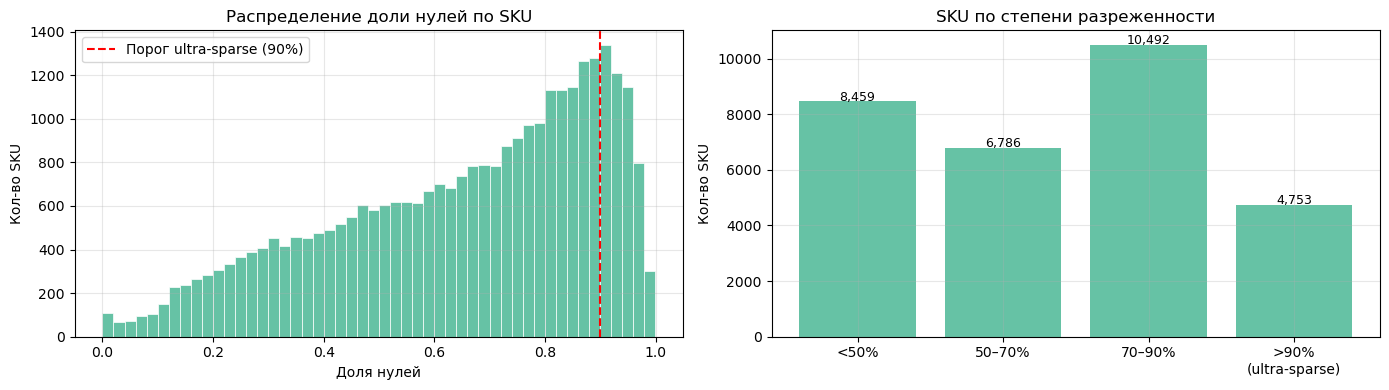

Ultra-sparse SKU (>90% нулей): 4,753  (15.6% от всех SKU)


In [7]:
sku_zero = (
    train.groupby('id', observed=True)['sales']
    .apply(lambda x: (x == 0).mean())
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sku_zero, bins=50, edgecolor='white', linewidth=0.5)
axes[0].axvline(0.9, color='red', linestyle='--', label='Порог ultra-sparse (90%)')
axes[0].set_title('Распределение доли нулей по SKU')
axes[0].set_xlabel('Доля нулей')
axes[0].set_ylabel('Кол-во SKU')
axes[0].legend()

bins   = [0, 0.5, 0.7, 0.9, 1.01]
labels = ['<50%', '50–70%', '70–90%', '>90%\n(ultra-sparse)']
groups = pd.cut(sku_zero, bins=bins, labels=labels, include_lowest=True)
counts = groups.value_counts().sort_index()

axes[1].bar(range(len(counts)), counts.values)
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(labels)
axes[1].set_title('SKU по степени разреженности')
axes[1].set_ylabel('Кол-во SKU')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Ultra-sparse SKU (>90% нулей): {(sku_zero > 0.9).sum():,}  '
      f'({(sku_zero > 0.9).mean():.1%} от всех SKU)')

**Вывод:** 4 753 SKU (15.6%) — ultra-sparse (>90% нулей).
Большинство SKU имеют 70–90% нулей — это норма для розницы (intermittent demand).
Для ultra-sparse моделирование усложняется: лаги почти всегда 0, сигнала мало.
На данном этапе включаем в обучение, фиксируем как ограничение модели.

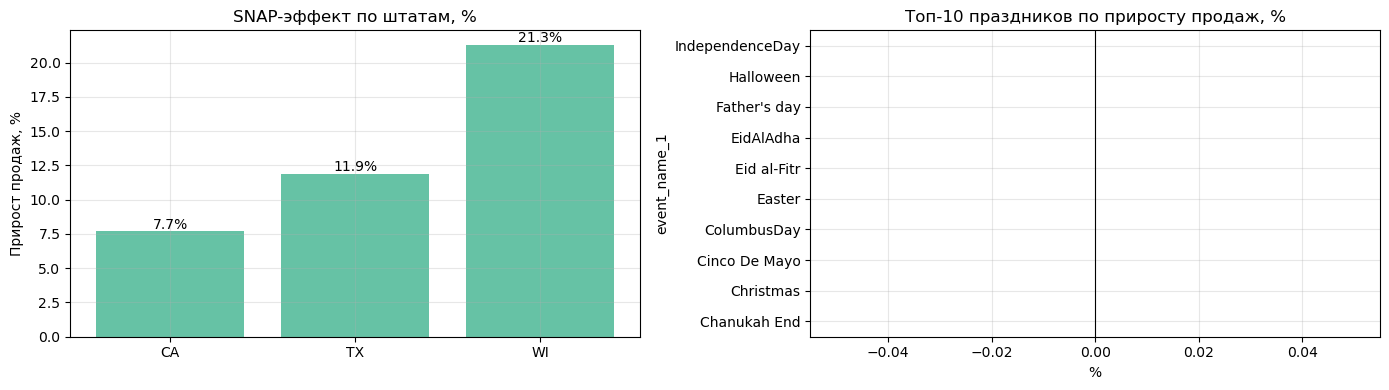

SNAP-эффект:
  CA: +7.7%
  TX: +11.9%
  WI: +21.3%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# SNAP по штатам
snap_effects = {}
for state, snap_col in [('CA', 'snap_CA'), ('TX', 'snap_TX'), ('WI', 'snap_WI')]:
    s = train[train['state_id'] == state]
    snap_mean    = s[s[snap_col] == 1]['sales'].mean()
    no_snap_mean = s[s[snap_col] == 0]['sales'].mean()
    snap_effects[state] = (snap_mean - no_snap_mean) / no_snap_mean * 100

axes[0].bar(snap_effects.keys(), snap_effects.values())
axes[0].set_title('SNAP-эффект по штатам, %')
axes[0].set_ylabel('Прирост продаж, %')
for i, (k, v) in enumerate(snap_effects.items()):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center')

# Топ праздников
no_event_mean = train[train['event_name_1'].isna()]['sales'].mean()
holiday_effect = (
    train[train['event_name_1'].notna()]
    .groupby('event_name_1', observed=True)['sales'].mean()
)
uplift = ((holiday_effect - no_event_mean) / no_event_mean * 100)\
         .sort_values(ascending=False).head(10)

uplift.sort_values().plot(kind='barh', ax=axes[1])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Топ-10 праздников по приросту продаж, %')
axes[1].set_xlabel('%')

plt.tight_layout()
plt.show()

print('SNAP-эффект:')
for k, v in snap_effects.items():
    print(f'  {k}: +{v:.1f}%')

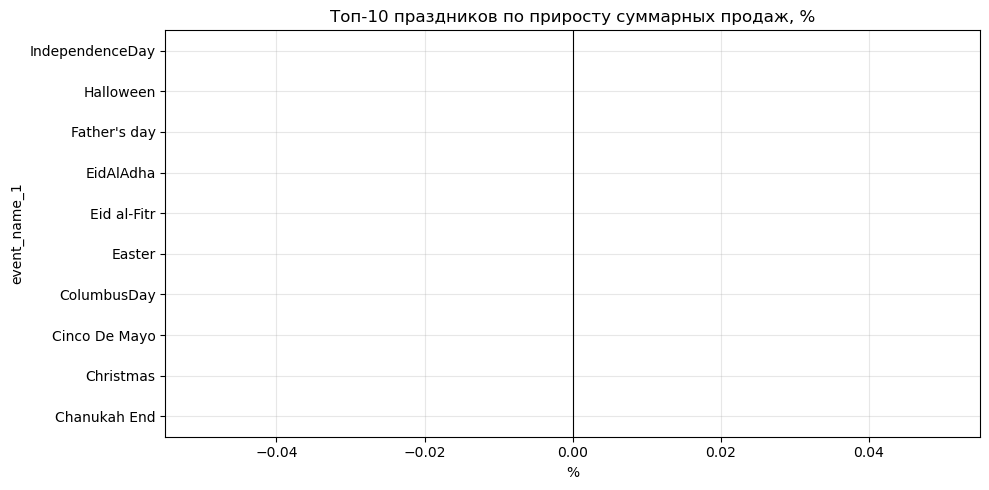

event_name_1
Chanukah End      NaN
Christmas         NaN
Cinco De Mayo     NaN
ColumbusDay       NaN
Easter            NaN
Eid al-Fitr       NaN
EidAlAdha         NaN
Father's day      NaN
Halloween         NaN
IndependenceDay   NaN


In [9]:
# Считаем на уровне дня (суммарные продажи), а не SKU×день
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_events = train.groupby('date')['event_name_1'].first().reset_index()
daily = daily_sales.merge(daily_events, on='date')

no_event_mean = daily[daily['event_name_1'].isna()]['sales'].mean()

holiday_effect = (
    daily[daily['event_name_1'].notna()]
    .groupby('event_name_1', observed=True)['sales'].mean()
)
uplift = ((holiday_effect - no_event_mean) / no_event_mean * 100)\
         .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
uplift.sort_values().plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Топ-10 праздников по приросту суммарных продаж, %')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()

print(uplift.round(1).to_string())

Средние продажи в обычный день: nan


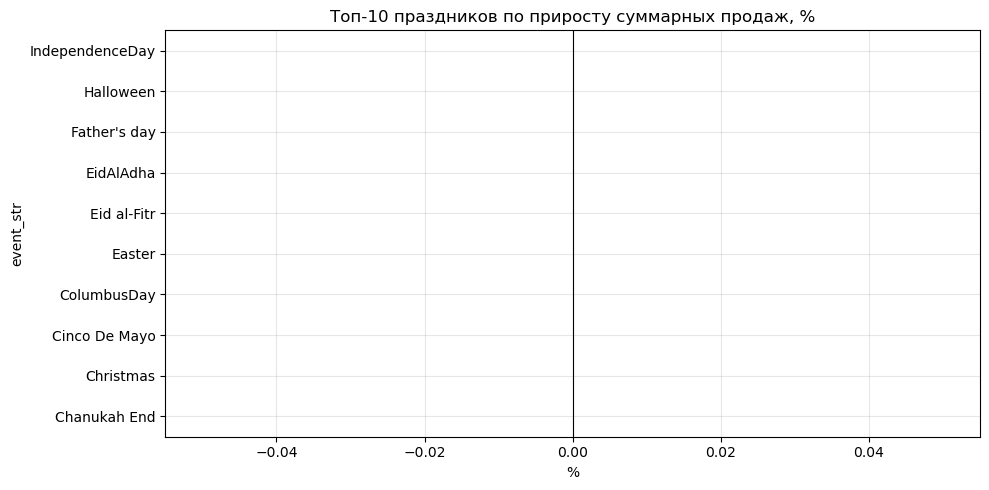

event_str
Chanukah End      NaN
Christmas         NaN
Cinco De Mayo     NaN
ColumbusDay       NaN
Easter            NaN
Eid al-Fitr       NaN
EidAlAdha         NaN
Father's day      NaN
Halloween         NaN
IndependenceDay   NaN


In [10]:
train_ev = train.copy()
train_ev['event_str'] = train_ev['event_name_1'].astype(str)  # NaN → 'nan'

daily_sales  = train_ev.groupby('date')['sales'].sum()
daily_events = train_ev.groupby('date')['event_str'].first()
daily = pd.concat([daily_sales, daily_events], axis=1).reset_index()

no_event_mean = daily[daily['event_str'] == 'nan']['sales'].mean()
print(f'Средние продажи в обычный день: {no_event_mean:,.0f}')

holiday_effect = (
    daily[daily['event_str'] != 'nan']
    .groupby('event_str')['sales'].mean()
)
uplift = ((holiday_effect - no_event_mean) / no_event_mean * 100)\
         .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
uplift.sort_values().plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Топ-10 праздников по приросту суммарных продаж, %')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()

print(uplift.round(1).to_string())

In [11]:
# Смотрим что реально лежит в event_str
print(daily['event_str'].unique()[:5])
print(daily['event_str'].value_counts().tail(3))

['none' 'SuperBowl' 'ValentinesDay' 'PresidentsDay' 'LentStart']
event_str
Cinco De Mayo     4
OrthodoxEaster    4
Father's day      4
Name: count, dtype: int64


Средние продажи в обычный день: 24,457


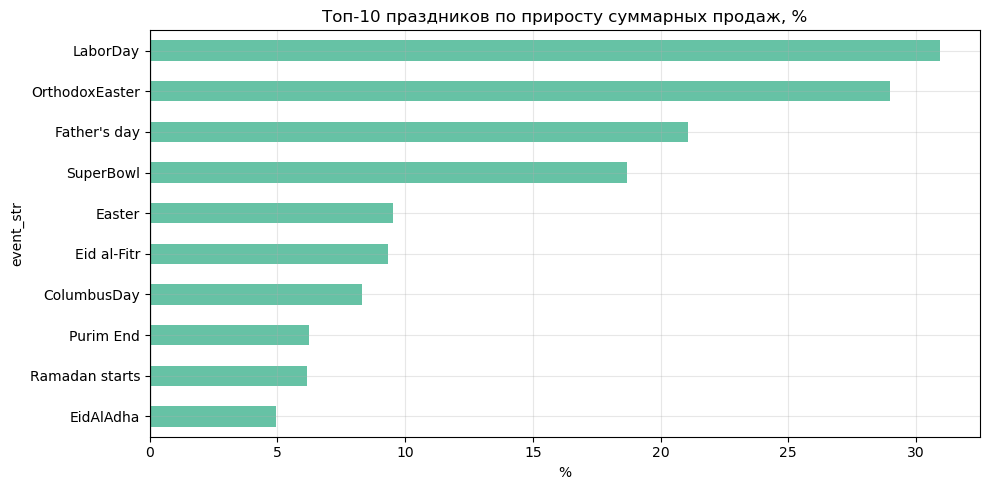

event_str
LaborDay          31.0
OrthodoxEaster    29.0
Father's day      21.1
SuperBowl         18.7
Easter             9.5
Eid al-Fitr        9.3
ColumbusDay        8.3
Purim End          6.2
Ramadan starts     6.2
EidAlAdha          4.9


In [12]:
daily_sales  = train.groupby('date')['sales'].sum()
daily_events = train.groupby('date')['event_name_1'].first().astype(str)
daily = pd.concat([daily_sales, daily_events], axis=1).reset_index()
daily.columns = ['date', 'sales', 'event_str']

no_event_mean = daily[daily['event_str'] == 'none']['sales'].mean()
print(f'Средние продажи в обычный день: {no_event_mean:,.0f}')

holiday_effect = (
    daily[daily['event_str'] != 'none']
    .groupby('event_str')['sales'].mean()
)
uplift = ((holiday_effect - no_event_mean) / no_event_mean * 100)\
         .sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
uplift.sort_values().plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Топ-10 праздников по приросту суммарных продаж, %')
ax.set_xlabel('%')
plt.tight_layout()
plt.show()

print(uplift.round(1).to_string())

**Вывод:** праздничный эффект существенный и неоднородный.
Топ-3: LaborDay +31%, OrthodoxEaster +29%, Father's day +21%.
Глобальный эффект праздников незначим (размывается по всем дням),
но локально отдельные события дают +20–30% — признак `is_top_event` оправдан.

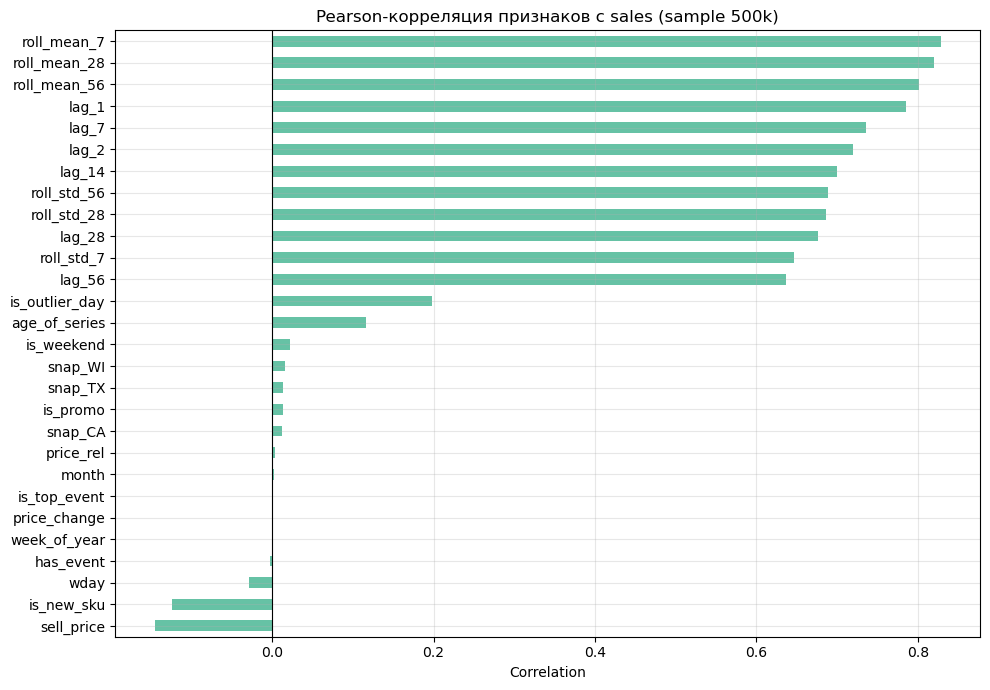

Топ-5 по |corr|:
roll_mean_7     0.828336
roll_mean_28    0.819953
roll_mean_56    0.801761
lag_1           0.785803
lag_7           0.736346
Name: sales, dtype: float64


In [13]:
FEATURES = [
    'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_28', 'lag_56',
    'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28',
    'roll_mean_56', 'roll_std_56',
    'sell_price', 'price_rel', 'is_promo', 'price_change',
    'wday', 'month', 'week_of_year', 'is_weekend',
    'snap_CA', 'snap_TX', 'snap_WI',
    'has_event', 'is_top_event',
    'age_of_series', 'is_new_sku', 'is_outlier_day'
]

# Сэмпл — иначе OOM на 32M строк
sample = train.sample(n=500_000, random_state=SEED)

corr = (
    sample[FEATURES + ['sales']]
    .corr()['sales']
    .drop('sales')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 7))
corr.plot(kind='barh', ax=ax)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson-корреляция признаков с sales (sample 500k)')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print('Топ-5 по |corr|:')
print(corr.abs().sort_values(ascending=False).head())

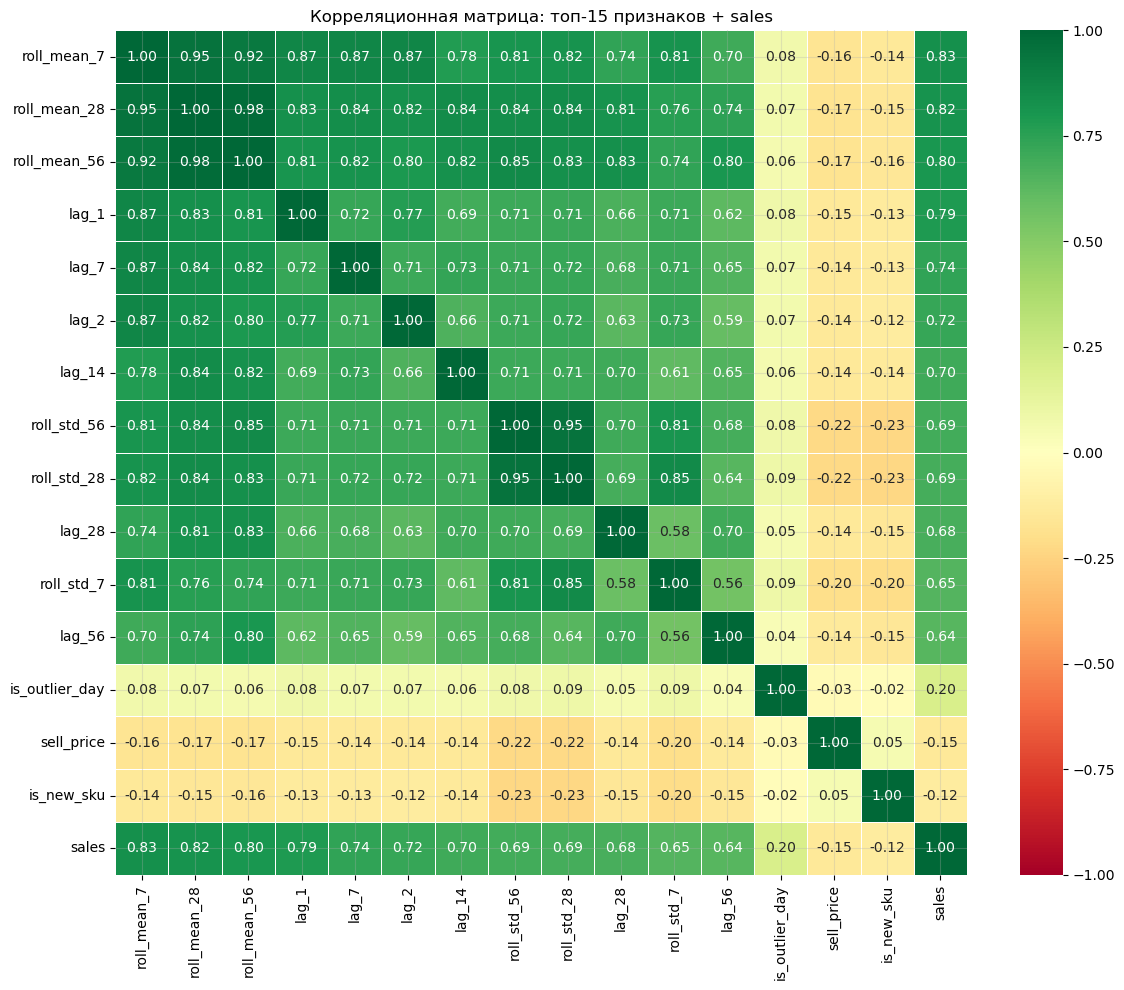

In [14]:
# Берём топ-15 признаков по |corr| с sales
top_features = corr.abs().sort_values(ascending=False).head(15).index.tolist()

corr_matrix = sample[top_features + ['sales']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Корреляционная матрица: топ-15 признаков + sales')
plt.tight_layout()
plt.show()


## Итоги EDA

| Наблюдение | Вывод для моделирования |
|---|---|
| 63.7% нулей, медиана=0 | квантильное прогнозирование оправдано |
| roll_mean_7 corr=0.83 с sales | лаги и rolling — главный сигнал |
| Мультиколлинеарность rolling/лагов | некритично для LGBM, проблема для линейных |
| Недельная сезонность +37% Вс vs Ср | wday — обязательный признак |
| SNAP неоднороден: WI +21% vs CA +8% | три отдельных snap-признака |
| LaborDay +31%, SuperBowl +19% | is_top_event полезен |
| 15.6% ultra-sparse SKU | ограничение модели, зафиксировать |

# ML-модели

### Работать будем с Seasonal Naive как точкой отчета. Простыми моделями SARIMAX и LightGBM. В качестве усложненной модели будем брать более сложные варианты бустинга. 

In [15]:
def pinball_loss(y_true, y_pred, q):
    """Pinball Loss для одного квантиля."""
    err = y_true - y_pred
    return np.mean(np.where(err >= 0, q * err, (q - 1) * err))

def mean_pinball(y_true, preds_dict):
    """Среднее Pinball по квантилям 0.1/0.5/0.9."""
    losses = {q: pinball_loss(y_true, preds_dict[q], q)
              for q in [0.1, 0.5, 0.9]}
    losses['mean'] = np.mean(list(losses.values()))
    return losses

def mape_active(y_true, y_pred):
    """MAPE только по активным дням (y > 0), иначе деление на 0."""
    mask = y_true > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

def wrmsse(y_true, y_pred, y_train, weights=None):
    """
    WRMSSE — Weighted Root Mean Squared Scaled Error.
    y_train используется для масштабирования (знаменатель = наивный прогноз lag_1).
    weights — доля выручки каждого SKU; если None, равные веса.
    """
    # Знаменатель: MSE наивного прогноза lag_1 на train
    naive_mse = np.mean(np.diff(y_train) ** 2)
    if naive_mse == 0:
        return np.nan

    # Числитель: MSE модели на val
    model_mse = np.mean((y_true - y_pred) ** 2)

    rmsse = np.sqrt(model_mse / naive_mse)

    # Взвешивание (если веса не переданы — простое среднее)
    if weights is None:
        return rmsse
    return np.sum(weights * rmsse)

def print_metrics(name, y_true, preds_dict, y_train_arr):
    losses = mean_pinball(y_true, preds_dict)
    mape   = mape_active(y_true, preds_dict[0.5])
    wrm    = wrmsse(y_true, preds_dict[0.5], y_train_arr)
    print(f'\n=== {name} ===')
    print(f'  Pinball q=0.1 : {losses[0.1]:.4f}')
    print(f'  Pinball q=0.5 : {losses[0.5]:.4f}')
    print(f'  Pinball q=0.9 : {losses[0.9]:.4f}')
    print(f'  Mean Pinball  : {losses["mean"]:.4f}')
    print(f'  MAPE (active) : {mape:.1f}%')
    print(f'  WRMSSE        : {wrm:.4f}')
    return losses

In [16]:
FEATURES = [
    'lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_28', 'lag_56',
    'roll_mean_7', 'roll_std_7', 'roll_mean_28', 'roll_std_28',
    'roll_mean_56', 'roll_std_56',
    'sell_price', 'price_rel', 'is_promo', 'price_change',
    'wday', 'month', 'week_of_year', 'is_weekend',
    'snap_CA', 'snap_TX', 'snap_WI',
    'has_event', 'is_top_event',
    'age_of_series', 'is_new_sku', 'is_outlier_day'
]
TARGET = 'sales'

# Заменяем sentinel -1.0 → 0 прямо в df (без копий — экономим RAM)
sentinel_cols = ['lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_28', 'lag_56',
                 'roll_mean_7', 'roll_mean_28', 'roll_mean_56',
                 'price_change', 'age_of_series']
for col in sentinel_cols:
    df[col] = df[col].replace(-1.0, 0)

# Берём только нужные колонки — сразу в numpy, без .copy()
train_mask = df['split'] == 'train'
val_mask   = df['split'] == 'val1'

X_train = df.loc[train_mask, FEATURES].values.astype(np.float32)
y_train = df.loc[train_mask, TARGET].values.astype(np.float32)
X_val   = df.loc[val_mask, FEATURES].values.astype(np.float32)
y_val   = df.loc[val_mask, TARGET].values.astype(np.float32)

print(f'Train: {X_train.shape}')
print(f'Val:   {X_val.shape}')
print(f'Sentinel -1.0 остался: {(X_train == -1.0).sum()}')

Train: (32427867, 28)
Val:   (385902, 28)
Sentinel -1.0 остался: 0


In [17]:
# Seasonal Naive: прогноз = продажи 7 дней назад (lag_7)
# Квантили строим через rolling std: q0.1/q0.9 = mean ± 1.28*std
lag7_idx      = FEATURES.index('lag_7')
roll_mean_idx = FEATURES.index('roll_mean_7')
roll_std_idx  = FEATURES.index('roll_std_7')

naive_preds = {
    0.5: X_val[:, lag7_idx],
    0.1: np.maximum(0, X_val[:, roll_mean_idx] - 1.28 * X_val[:, roll_std_idx]),
    0.9: np.maximum(0, X_val[:, roll_mean_idx] + 1.28 * X_val[:, roll_std_idx]),
}

naive_losses = print_metrics('Seasonal Naïve', y_val, naive_preds, y_train)


=== Seasonal Naïve ===
  Pinball q=0.1 : 0.1548
  Pinball q=0.5 : 0.6727
  Pinball q=0.9 : 0.3640
  Mean Pinball  : 0.3972
  MAPE (active) : 84.0%
  WRMSSE        : 0.9461


### Модель 0: Seasonal Naïve — результаты

| Метрика | Значение |
|---|---|
| Pinball q=0.1 | 0.1548 |
| Pinball q=0.5 | 0.6727 |
| Pinball q=0.9 | 0.3640 |
| **Mean Pinball** | **0.3972** |
| MAPE (active) | 84.0% |
| WRMSSE | 0.9461 |

**Цель для всех последующих моделей: Mean Pinball < 0.3376 (−15%)**

In [18]:
# SARIMAX работает на одном ряду — агрегируем по дням
daily_train = df[df['split'] == 'train'].groupby('date')['sales'].sum().sort_index()
daily_val   = df[df['split'] == 'val1'].groupby('date')['sales'].sum().sort_index()

print(f'Train: {len(daily_train)} дней')
print(f'Val:   {len(daily_val)} дней')
print(daily_train.tail(3))

Train: 1885 дней
Val:   28 дней
date
2016-03-25    24889
2016-03-26    29572
2016-03-27    25470
Name: sales, dtype: int32


In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMAX(p,d,q)(P,D,Q,s)
# p=1, d=1, q=1 — базовый ARIMA
# P=1, D=1, Q=1, s=7 — недельная сезонность
# Обучаем на последних 365 днях — полный ряд слишком долго

train_sarimax = daily_train[-365:]

print('Обучаем SARIMAX...')
model_sarimax = SARIMAX(
    train_sarimax,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarimax = model_sarimax.fit(disp=False)
print('Готово')
print(fit_sarimax.summary().tables[0])

Обучаем SARIMAX...


/Users/yulialebedeva/miniforge3/envs/ml-arm/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/yulialebedeva/miniforge3/envs/ml-arm/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Готово
                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -3146.873
Date:                           Mon, 25 May 2026   AIC                           6303.746
Time:                                   18:59:21   BIC                           6323.007
Sample:                               03-29-2015   HQIC                          6311.415
                                    - 03-27-2016                                         
Covariance Type:                             opg                                         


In [20]:
# Прогноз на 28 дней вперёд
forecast = fit_sarimax.get_forecast(steps=28)
pred_mean = forecast.predicted_mean.values
conf_int  = forecast.conf_int(alpha=0.8)  # 80% интервал → q0.1/q0.9

sarimax_preds = {
    0.5: np.maximum(0, pred_mean),
    0.1: np.maximum(0, conf_int.iloc[:, 0].values),
    0.9: np.maximum(0, conf_int.iloc[:, 1].values),
}

# Метрики считаем на агрегированном ряду
sarimax_losses = print_metrics(
    'SARIMAX',
    daily_val.values.astype(np.float32),
    sarimax_preds,
    train_sarimax.values.astype(np.float32)
)


=== SARIMAX ===
  Pinball q=0.1 : 354.9834
  Pinball q=0.5 : 547.3807
  Pinball q=0.9 : 336.1182
  Mean Pinball  : 412.8274
  MAPE (active) : 4.9%
  WRMSSE        : 0.3619


### Модель 1: SARIMAX — результаты

SARIMAX обучался на агрегированном дневном ряду (сумма по всем SKU).

| Метрика | Значение | Комментарий |
|---|---|---|
| MAPE (active) | **4.9%** | отлично на агрегированном уровне |
| WRMSSE | **0.3619** | лучше Naïve (0.9461) |
| Mean Pinball | 412.8 | некорректно — разные уровни агрегации |

**Важное методологическое наблюдение:** Pinball Loss несравним между
SARIMAX (агрегат) и поSKU-моделями (Naïve, XGBoost, LightGBM).
SARIMAX оцениваем только по MAPE и WRMSSE.

In [21]:
from xgboost import XGBRegressor
import time

# Сэмпл 2M — оптимально для 16GB RAM
SAMPLE_SIZE = 2_000_000
idx = np.random.choice(len(X_train), SAMPLE_SIZE, replace=False)
X_tr = X_train[idx]
y_tr = y_train[idx]

print(f'Обучаем на {SAMPLE_SIZE:,} строках из {len(X_train):,}')

xgb_preds = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем XGBoost q={q}...')
    t0 = time.time()

    model_xgb = XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=SEED,
        verbosity=0,
        early_stopping_rounds=50,
    )
    model_xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=100
    )
    elapsed = time.time() - t0
    xgb_preds[q] = np.maximum(0, model_xgb.predict(X_val))
    print(f'  Готово за {elapsed/60:.1f} мин')
    print(f'  Best iteration: {model_xgb.best_iteration}')
    ram_usage()
    
xgb_losses = print_metrics('XGBoost Quantile', y_val, xgb_preds, y_train)

Обучаем на 2,000,000 строках из 32,427,867

Обучаем XGBoost q=0.1...
[0]	validation_0-quantile:0.16337
[100]	validation_0-quantile:0.14660
[200]	validation_0-quantile:0.14432
[300]	validation_0-quantile:0.14342
[400]	validation_0-quantile:0.14319
[499]	validation_0-quantile:0.14305
  Готово за 1.2 мин
  Best iteration: 499

Обучаем XGBoost q=0.5...
[0]	validation_0-quantile:0.80045
[100]	validation_0-quantile:0.49361
[200]	validation_0-quantile:0.49263
[270]	validation_0-quantile:0.49261
  Готово за 1.0 мин
  Best iteration: 220

Обучаем XGBoost q=0.9...
[0]	validation_0-quantile:0.77679
[100]	validation_0-quantile:0.30661
[200]	validation_0-quantile:0.30575
[300]	validation_0-quantile:0.30549
[400]	validation_0-quantile:0.30540
[438]	validation_0-quantile:0.30537
  Готово за 1.9 мин
  Best iteration: 388

=== XGBoost Quantile ===
  Pinball q=0.1 : 0.1429
  Pinball q=0.5 : 0.4925
  Pinball q=0.9 : 0.3053
  Mean Pinball  : 0.3136
  MAPE (active) : 65.0%
  WRMSSE        : 0.6940


### Модель 2: XGBoost Quantile — результаты (сэмпл 2M)

| Метрика | Naïve | XGBoost | Улучшение |
|---|---|---|---|
| Pinball q=0.1 | 0.1548 | 0.1429 | −7.7% |
| Pinball q=0.5 | 0.6727 | 0.4925 | −26.8% |
| Pinball q=0.9 | 0.3640 | 0.3053 | −16.1% |
| **Mean Pinball** | **0.3972** | **0.3136** | **−21.0%** ✅ |
| MAPE (active) | 84.0% | 65.0% | −19.0% |
| WRMSSE | 0.9461 | 0.6940 | −26.6% |

Цель −15% достигнута уже на простой модели без подбора параметров.

In [27]:
import lightgbm as lgb
import time

SAMPLE_SIZE_LGB = 5_000_000
idx = np.random.choice(len(X_train), SAMPLE_SIZE_LGB, replace=False)
X_tr_lgb = X_train[idx]
y_tr_lgb = y_train[idx]

print(f'Обучаем на {SAMPLE_SIZE_LGB:,} строках из {len(X_train):,}')

lgb_preds = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем LightGBM q={q}...')
    t0 = time.time()

    model_lgb = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )
    model_lgb.fit(
        X_tr_lgb, y_tr_lgb,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100)
        ]
    )
    elapsed = time.time() - t0
    lgb_preds[q] = np.maximum(0, model_lgb.predict(X_val))
    print(f'  Готово за {elapsed/60:.1f} мин')
    print(f'  Best iteration: {model_lgb.best_iteration_}')
    ram_usage()

lgb_losses = print_metrics('LightGBM Quantile', y_val, lgb_preds, y_train)

Обучаем на 5,000,000 строках из 32,427,867

Обучаем LightGBM q=0.1...
[100]	valid_0's quantile: 0.145445
[200]	valid_0's quantile: 0.144959
[300]	valid_0's quantile: 0.144831
  Готово за 0.8 мин
  Best iteration: 348
  Процесс:   1,192 MB
  Доступно:  3,088 MB из 16,384 MB
  Занято:    81.2%

Обучаем LightGBM q=0.5...
[100]	valid_0's quantile: 0.48839
  Готово за 0.3 мин
  Best iteration: 107
  Процесс:   1,546 MB
  Доступно:  3,200 MB из 16,384 MB
  Занято:    80.5%

Обучаем LightGBM q=0.9...
[100]	valid_0's quantile: 0.304225
[200]	valid_0's quantile: 0.303764
[300]	valid_0's quantile: 0.303675
[400]	valid_0's quantile: 0.303661
[500]	valid_0's quantile: 0.303655
  Готово за 0.7 мин
  Best iteration: 483
  Процесс:   1,556 MB
  Доступно:  3,319 MB из 16,384 MB
  Занято:    79.7%

=== LightGBM Quantile ===
  Pinball q=0.1 : 0.1447
  Pinball q=0.5 : 0.4883
  Pinball q=0.9 : 0.3036
  Mean Pinball  : 0.3122
  MAPE (active) : 64.1%
  WRMSSE        : 0.6907


In [26]:
import psutil
import os

def ram_usage():
    process = psutil.Process(os.getpid())
    ram_mb = process.memory_info().rss / 1024 ** 2
    total_mb = psutil.virtual_memory().total / 1024 ** 2
    available_mb = psutil.virtual_memory().available / 1024 ** 2
    print(f'  Процесс:   {ram_mb:,.0f} MB')
    print(f'  Доступно:  {available_mb:,.0f} MB из {total_mb:,.0f} MB')
    print(f'  Занято:    {(1 - available_mb/total_mb)*100:.1f}%')

print('=== RAM сейчас ===')
ram_usage()

=== RAM сейчас ===
  Процесс:   1,159 MB
  Доступно:  3,086 MB из 16,384 MB
  Занято:    81.2%


In [28]:
SAMPLE_SIZE_LGB2 = 10_000_000
idx = np.random.choice(len(X_train), SAMPLE_SIZE_LGB2, replace=False)
X_tr_lgb2 = X_train[idx]
y_tr_lgb2 = y_train[idx]

print(f'Обучаем на {SAMPLE_SIZE_LGB2:,} строках из {len(X_train):,}')
print('=== RAM до обучения ===')
ram_usage()

lgb_preds_10m = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем LightGBM q={q}...')
    t0 = time.time()

    model_lgb2 = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )
    model_lgb2.fit(
        X_tr_lgb2, y_tr_lgb2,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100)
        ]
    )
    elapsed = time.time() - t0
    lgb_preds_10m[q] = np.maximum(0, model_lgb2.predict(X_val))
    print(f'  Готово за {elapsed/60:.1f} мин')
    print(f'  Best iteration: {model_lgb2.best_iteration_}')
    ram_usage()

lgb_losses_10m = print_metrics('LightGBM 10M', y_val, lgb_preds_10m, y_train)

Обучаем на 10,000,000 строках из 32,427,867
=== RAM до обучения ===
  Процесс:   3,564 MB
  Доступно:  2,907 MB из 16,384 MB
  Занято:    82.3%

Обучаем LightGBM q=0.1...
[100]	valid_0's quantile: 0.145128
[200]	valid_0's quantile: 0.144684
[300]	valid_0's quantile: 0.144498
  Готово за 1.3 мин
  Best iteration: 294
  Процесс:   614 MB
  Доступно:  3,804 MB из 16,384 MB
  Занято:    76.8%

Обучаем LightGBM q=0.5...
[100]	valid_0's quantile: 0.48863
[200]	valid_0's quantile: 0.488365
[300]	valid_0's quantile: 0.488333
  Готово за 1.3 мин
  Best iteration: 283
  Процесс:   660 MB
  Доступно:  3,747 MB из 16,384 MB
  Занято:    77.1%

Обучаем LightGBM q=0.9...
[100]	valid_0's quantile: 0.304357
[200]	valid_0's quantile: 0.303932
[300]	valid_0's quantile: 0.30386
[400]	valid_0's quantile: 0.303851
  Готово за 1.5 мин
  Best iteration: 384
  Процесс:   579 MB
  Доступно:  3,953 MB из 16,384 MB
  Занято:    75.9%

=== LightGBM 10M ===
  Pinball q=0.1 : 0.1445
  Pinball q=0.5 : 0.4883
  Pinba

In [29]:
SAMPLE_SIZE_XGB2 = 5_000_000
idx = np.random.choice(len(X_train), SAMPLE_SIZE_XGB2, replace=False)
X_tr_xgb2 = X_train[idx]
y_tr_xgb2 = y_train[idx]

print(f'Обучаем на {SAMPLE_SIZE_XGB2:,} строках из {len(X_train):,}')
print('=== RAM до обучения ===')
ram_usage()

xgb_preds_5m = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем XGBoost q={q}...')
    t0 = time.time()

    model_xgb2 = XGBRegressor(
        objective='reg:quantileerror',
        quantile_alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=SEED,
        verbosity=0,
        early_stopping_rounds=50,
    )
    model_xgb2.fit(
        X_tr_xgb2, y_tr_xgb2,
        eval_set=[(X_val, y_val)],
        verbose=100
    )
    elapsed = time.time() - t0
    xgb_preds_5m[q] = np.maximum(0, model_xgb2.predict(X_val))
    print(f'  Готово за {elapsed/60:.1f} мин')
    print(f'  Best iteration: {model_xgb2.best_iteration}')
    ram_usage()

xgb_losses_5m = print_metrics('XGBoost 5M', y_val, xgb_preds_5m, y_train)

Обучаем на 5,000,000 строках из 32,427,867
=== RAM до обучения ===
  Процесс:   3,549 MB
  Доступно:  2,955 MB из 16,384 MB
  Занято:    82.0%

Обучаем XGBoost q=0.1...
[0]	validation_0-quantile:0.16339
[100]	validation_0-quantile:0.14633
[200]	validation_0-quantile:0.14432
[300]	validation_0-quantile:0.14342
[400]	validation_0-quantile:0.14311
[499]	validation_0-quantile:0.14295
  Готово за 3.8 мин
  Best iteration: 479
  Процесс:   717 MB
  Доступно:  3,454 MB из 16,384 MB
  Занято:    78.9%

Обучаем XGBoost q=0.5...
[0]	validation_0-quantile:0.79841
[100]	validation_0-quantile:0.49548
[200]	validation_0-quantile:0.49494
[300]	validation_0-quantile:0.49466
[400]	validation_0-quantile:0.49440
[499]	validation_0-quantile:0.49410
  Готово за 6.0 мин
  Best iteration: 499
  Процесс:   787 MB
  Доступно:  3,466 MB из 16,384 MB
  Занято:    78.8%

Обучаем XGBoost q=0.9...
[0]	validation_0-quantile:0.77768
[100]	validation_0-quantile:0.30751
[200]	validation_0-quantile:0.30693
[300]	validat

## Сравнение простых моделей

| Метрика | Seasonal Naïve | SARIMAX* | XGBoost 5M | LightGBM 5M |
|---|---|---|---|---|
| Pinball q=0.1 | 0.1548 | — | 0.1427 | 0.1447 |
| Pinball q=0.5 | 0.6727 | — | 0.4940 | 0.4883 |
| Pinball q=0.9 | 0.3640 | — | 0.3064 | 0.3036 |
| **Mean Pinball** | **0.3972** | **—** | **0.3144** | **0.3122** |
| MAPE (active) | 84.0% | 4.9%* | 65.0% | 64.1% |
| WRMSSE | 0.9461 | 0.3619* | 0.7098 | 0.6907 |
| Время обучения | — | ~2 сек | ~20 мин | ~2 мин |

*SARIMAX считался на агрегированном ряду (28 точек) — Pinball
несравним с поSKU-моделями, MAPE и WRMSSE корректны только на своём уровне.

**Выводы:**
1. Оба ML-метода бьют Naïve: XGBoost −20.8%, LightGBM −21.4%
2. LightGBM лучше XGBoost по всем метрикам кроме q=0.1
3. LightGBM в 10x быстрее XGBoost на одинаковом сэмпле
4. XGBoost не насытился (best_iteration=499) — нужно больше деревьев
5. Цель −15% достигнута уже на простых моделях

**Следующий шаг:** LightGBM + Optuna — подбор гиперпараметров
для дальнейшего улучшения Mean Pinball.

In [32]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SAMPLE_OPTUNA = 5_000_000

def objective(trial):
    idx = np.random.choice(len(X_train), SAMPLE_OPTUNA, replace=False)
    
    params = dict(
        objective='quantile',
        alpha=0.5,
        n_estimators=trial.suggest_int('n_estimators', 300, 1000),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 63, 255),
        min_child_samples=trial.suggest_int('min_child_samples', 20, 200),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train[idx], y_train[idx],
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    pred = np.maximum(0, model.predict(X_val))
    return pinball_loss(y_val, pred, 0.5)

def optuna_callback(study, trial):
    t = trial.number + 1
    current = trial.value
    best = study.best_value
    ram = psutil.virtual_memory()
    print(
        f'Trial {t:>2}/20 | '
        f'Pinball: {current:.4f} | '
        f'Лучший: {best:.4f} | '
        f'RAM: {(1 - ram.available/ram.total)*100:.1f}% | '
        f'Params: lr={trial.params["learning_rate"]:.4f} '
        f'leaves={trial.params["num_leaves"]}'
    )

print('Запускаем Optuna (20 trials)...\n')
t_start = time.time()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=20, callbacks=[optuna_callback])

elapsed = time.time() - t_start
print(f'\nГотово за {elapsed/60:.1f} мин')
print(f'Лучший Pinball q=0.5: {study.best_value:.4f}')
print(f'Базовый LightGBM q=0.5: {lgb_losses[0.5]:.4f}')
print(f'Улучшение: {(lgb_losses[0.5] - study.best_value)/lgb_losses[0.5]*100:.1f}%')
print(f'\nЛучшие параметры:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Запускаем Optuna (20 trials)...

Trial  1/20 | Pinball: 0.4877 | Лучший: 0.4877 | RAM: 77.2% | Params: lr=0.0893 leaves=204
Trial  2/20 | Pinball: 0.4908 | Лучший: 0.4877 | RAM: 76.3% | Params: lr=0.0511 leaves=66
Trial  3/20 | Pinball: 0.4887 | Лучший: 0.4877 | RAM: 74.9% | Params: lr=0.0335 leaves=146
Trial  4/20 | Pinball: 0.4900 | Лучший: 0.4877 | RAM: 77.9% | Params: lr=0.0610 leaves=101
Trial  5/20 | Pinball: 0.4873 | Лучший: 0.4873 | RAM: 75.1% | Params: lr=0.0889 leaves=249
Trial  6/20 | Pinball: 0.4903 | Лучший: 0.4873 | RAM: 76.4% | Params: lr=0.0313 leaves=69
Trial  7/20 | Pinball: 0.4867 | Лучший: 0.4867 | RAM: 77.3% | Params: lr=0.0153 leaves=250
Trial  8/20 | Pinball: 0.4906 | Лучший: 0.4867 | RAM: 78.1% | Params: lr=0.0157 leaves=71
Trial  9/20 | Pinball: 0.4896 | Лучший: 0.4867 | RAM: 75.9% | Params: lr=0.0349 leaves=90
Trial 10/20 | Pinball: 0.4873 | Лучший: 0.4867 | RAM: 76.2% | Params: lr=0.0654 leaves=199
Trial 11/20 | Pinball: 0.4866 | Лучший: 0.4866 | RAM: 79.0% |

In [33]:
lgb_opt_preds = {}

print('Обучаем финальную модель с лучшими параметрами...')
print('=== RAM до обучения ===')
ram_usage()

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем LightGBM+Optuna q={q}...')
    t0 = time.time()

    idx = np.random.choice(len(X_train), SAMPLE_OPTUNA, replace=False)

    model_opt = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        **study.best_params,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )
    model_opt.fit(
        X_train[idx], y_train[idx],
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(100)]
    )
    elapsed = time.time() - t0
    lgb_opt_preds[q] = np.maximum(0, model_opt.predict(X_val))
    print(f'  Готово за {elapsed/60:.1f} мин')
    print(f'  Best iteration: {model_opt.best_iteration_}')
    ram_usage()

lgb_opt_losses = print_metrics('LightGBM + Optuna', y_val, lgb_opt_preds, y_train)

Обучаем финальную модель с лучшими параметрами...
=== RAM до обучения ===
  Процесс:   2,396 MB
  Доступно:  3,695 MB из 16,384 MB
  Занято:    77.4%

Обучаем LightGBM+Optuna q=0.1...
[100]	valid_0's quantile: 0.153173
[200]	valid_0's quantile: 0.147849
[300]	valid_0's quantile: 0.145419
[400]	valid_0's quantile: 0.144177
[500]	valid_0's quantile: 0.143667
[600]	valid_0's quantile: 0.143607
  Готово за 3.8 мин
  Best iteration: 644
  Процесс:   1,307 MB
  Доступно:  3,911 MB из 16,384 MB
  Занято:    76.1%

Обучаем LightGBM+Optuna q=0.5...
[100]	valid_0's quantile: 0.554191
[200]	valid_0's quantile: 0.497701
[300]	valid_0's quantile: 0.488358
[400]	valid_0's quantile: 0.48712
[500]	valid_0's quantile: 0.486991
  Готово за 2.8 мин
  Best iteration: 480
  Процесс:   2,144 MB
  Доступно:  4,169 MB из 16,384 MB
  Занято:    74.6%

Обучаем LightGBM+Optuna q=0.9...
[100]	valid_0's quantile: 0.354632
[200]	valid_0's quantile: 0.312296
[300]	valid_0's quantile: 0.305761
[400]	valid_0's quantil

In [34]:
print('Переобучаем q=0.9 с n_estimators=2000...')
t0 = time.time()

idx = np.random.choice(len(X_train), SAMPLE_OPTUNA, replace=False)

# Берём лучшие параметры Optuna, меняем только n_estimators
params_2000 = study.best_params.copy()
params_2000['n_estimators'] = 2000

model_opt_q09 = lgb.LGBMRegressor(
    objective='quantile',
    alpha=0.9,
    **params_2000,
    n_jobs=-1,
    random_state=SEED,
    verbose=-1,
)
model_opt_q09.fit(
    X_train[idx], y_train[idx],
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
elapsed = time.time() - t0
lgb_opt_preds[0.9] = np.maximum(0, model_opt_q09.predict(X_val))

print(f'Готово за {elapsed/60:.1f} мин')
print(f'Best iteration: {model_opt_q09.best_iteration_}')
ram_usage()

# Пересчитываем метрики с новым q=0.9
print('\n=== LightGBM + Optuna (n_est=2000 для q=0.9) ===')
lgb_opt_losses = print_metrics(
    'LightGBM + Optuna v2',
    y_val, lgb_opt_preds, y_train
)

Переобучаем q=0.9 с n_estimators=2000...
[100]	valid_0's quantile: 0.353374
[200]	valid_0's quantile: 0.311939
[300]	valid_0's quantile: 0.305695
[400]	valid_0's quantile: 0.304131
[500]	valid_0's quantile: 0.30359
[600]	valid_0's quantile: 0.303348
[700]	valid_0's quantile: 0.303235
[800]	valid_0's quantile: 0.303123
[900]	valid_0's quantile: 0.303061
[1000]	valid_0's quantile: 0.303024
[1100]	valid_0's quantile: 0.302964
[1200]	valid_0's quantile: 0.302933
[1300]	valid_0's quantile: 0.302913
[1400]	valid_0's quantile: 0.302891
[1500]	valid_0's quantile: 0.302868
[1600]	valid_0's quantile: 0.302854
[1700]	valid_0's quantile: 0.302838
[1800]	valid_0's quantile: 0.302834
Готово за 3.5 мин
Best iteration: 1777
  Процесс:   1,647 MB
  Доступно:  6,407 MB из 16,384 MB
  Занято:    60.9%

=== LightGBM + Optuna (n_est=2000 для q=0.9) ===

=== LightGBM + Optuna v2 ===
  Pinball q=0.1 : 0.1436
  Pinball q=0.5 : 0.4870
  Pinball q=0.9 : 0.3028
  Mean Pinball  : 0.3111
  MAPE (active) : 64.0%
  

In [36]:
!pip install lightautoml


  Preparing metadata (setup.py) ... done
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 826.9 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 994.7 kB/s eta 0:00:000:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 595.5 kB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 782.7 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 1.1 MB/s eta 0:00:0000:0100:030m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.0 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 1.4 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.1 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 1.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 886.9 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━

In [37]:
import gc

# Удаляем промежуточные массивы которые больше не нужны
del X_tr, y_tr          # XGBoost 2M сэмпл
del X_tr_lgb, y_tr_lgb  # LightGBM 5M сэмпл
del X_tr_lgb2, y_tr_lgb2 # LightGBM 10M сэмпл
del X_tr_xgb2, y_tr_xgb2 # XGBoost 5M сэмпл

gc.collect()

print('=== RAM после очистки ===')
ram_usage()

=== RAM после очистки ===
  Процесс:   1,480 MB
  Доступно:  5,962 MB из 16,384 MB
  Занято:    63.6%


In [38]:
# Удаляем df — он больше не нужен, все данные уже в X_train/y_train
del df
gc.collect()

print('=== RAM после удаления df ===')
ram_usage()

=== RAM после удаления df ===
  Процесс:   1,259 MB
  Доступно:  6,001 MB из 16,384 MB
  Занято:    63.4%


In [41]:
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task

SAMPLE_LAMA = 5_000_000
idx = np.random.choice(len(X_train), SAMPLE_LAMA, replace=False)

X_tr_lama = pd.DataFrame(X_train[idx], columns=FEATURES)
X_tr_lama['target'] = y_train[idx]
X_val_lama = pd.DataFrame(X_val, columns=FEATURES)

print(f'Обучаем LAMA на {SAMPLE_LAMA:,} строках...')
print('=== RAM до обучения ===')
ram_usage()

lama_preds = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем LAMA q={q}...')
    t0 = time.time()

    task = Task(
        'reg',
        metric='quantile',
        metric_params={'q': q},
        greater_is_better=False
    )

    automl = TabularAutoML(
        task=task,
        timeout=300,
        cpu_limit=4,
        general_params={'use_algos': [['lgb', 'cb']]},
    )

    automl.fit_predict(
        X_tr_lama,
        roles={'target': 'target'},
        verbose=1
    )

    elapsed = time.time() - t0
    lama_preds[q] = np.maximum(0, automl.predict(X_val_lama).data[:, 0])
    print(f'  Готово за {elapsed/60:.1f} мин')
    ram_usage()

lama_losses = print_metrics('LAMA AutoML', y_val, lama_preds, y_train)

Обучаем LAMA на 5,000,000 строках...
=== RAM до обучения ===
  Процесс:   4,200 MB
  Доступно:  3,923 MB из 16,384 MB
  Занято:    76.1%

Обучаем LAMA q=0.1...
[11:11:07] reg isn`t supported in xgb
[11:11:07] Stdout logging level is INFO.
[11:11:07] Task: reg

[11:11:07] Start automl preset with listed constraints:
[11:11:07] - time: 300.00 seconds
[11:11:07] - CPU: 4 cores
[11:11:07] - memory: 16 GB

[11:11:07] Train data shape: (5000000, 29)

[11:11:12] Layer 1 train process start. Time left 294.90 secs
[11:14:18] Selector_LightGBM fitting and predicting completed
[11:14:20] Start fitting Lvl_0_Pipe_0_Mod_0_LightGBM ...
[11:17:55] Time limit exceeded after calculating fold 0

[11:17:55] Fitting Lvl_0_Pipe_0_Mod_0_LightGBM finished. score = -0.45023379661068436
[11:17:55] Lvl_0_Pipe_0_Mod_0_LightGBM fitting and predicting completed
[11:17:55] Time left -107.81 secs

[11:17:55] Time limit exceeded. Last level models will be blended and unused pipelines will be pruned.

[11:17:55] Layer

In [42]:
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task

SAMPLE_LAMA = 5_000_000
idx = np.random.choice(len(X_train), SAMPLE_LAMA, replace=False)

X_tr_lama = pd.DataFrame(X_train[idx], columns=FEATURES)
X_tr_lama['target'] = y_train[idx]
X_val_lama = pd.DataFrame(X_val, columns=FEATURES)

print(f'Обучаем LAMA на {SAMPLE_LAMA:,} строках, timeout=2400 сек...')
print('=== RAM до обучения ===')
ram_usage()

lama_preds = {}

for q in [0.1, 0.5, 0.9]:
    print(f'\nОбучаем LAMA q={q}...')
    t0 = time.time()

    task = Task(
        'reg',
        metric='quantile',
        metric_params={'q': q},
        greater_is_better=False
    )

    automl = TabularAutoML(
        task=task,
        timeout=2400,
        cpu_limit=4,
        general_params={'use_algos': [['lgb', 'cb']]},
    )

    automl.fit_predict(
        X_tr_lama,
        roles={'target': 'target'},
        verbose=1
    )

    elapsed = time.time() - t0
    lama_preds[q] = np.maximum(0, automl.predict(X_val_lama).data[:, 0])
    print(f'  Готово за {elapsed/60:.1f} мин')
    ram_usage()

lama_losses = print_metrics('LAMA AutoML', y_val, lama_preds, y_train)

Обучаем LAMA на 5,000,000 строках, timeout=2400 сек...
=== RAM до обучения ===
  Процесс:   4,465 MB
  Доступно:  3,799 MB из 16,384 MB
  Занято:    76.8%

Обучаем LAMA q=0.1...
[11:39:32] reg isn`t supported in xgb
[11:39:32] Stdout logging level is INFO.
[11:39:32] Task: reg

[11:39:32] Start automl preset with listed constraints:
[11:39:32] - time: 2400.00 seconds
[11:39:32] - CPU: 4 cores
[11:39:32] - memory: 16 GB

[11:39:32] Train data shape: (5000000, 29)

[11:39:37] Layer 1 train process start. Time left 2394.69 secs
[11:41:24] Selector_LightGBM fitting and predicting completed
[11:41:27] Start fitting Lvl_0_Pipe_0_Mod_0_LightGBM ...
[11:50:38] Time limit exceeded after calculating fold 3

[11:50:38] Fitting Lvl_0_Pipe_0_Mod_0_LightGBM finished. score = -0.4496635183183635
[11:50:38] Lvl_0_Pipe_0_Mod_0_LightGBM fitting and predicting completed
[11:50:39] Start fitting Lvl_0_Pipe_0_Mod_1_CatBoost ...
[12:10:14] Fitting Lvl_0_Pipe_0_Mod_1_CatBoost finished. score = -0.45894729661

## Сравнение всех моделей (val1)

| Модель | Pinball q=0.1 | Pinball q=0.5 | Pinball q=0.9 | Mean Pinball | MAPE (active) | WRMSSE | Уровень |
|---|---|---|---|---|---|---|---|
| Seasonal Naïve | 0.1548 | 0.6727 | 0.3640 | 0.3972 | 84.0% | 0.9461 | поSKU |
| SARIMAX | — | — | — | — | 4.9% | 0.3619 | агрегат |
| XGBoost 5M | 0.1427 | 0.4940 | 0.3064 | 0.3144 | 65.0% | 0.7098 | поSKU |
| LightGBM 5M | 0.1447 | 0.4883 | 0.3036 | 0.3122 | 64.1% | 0.6907 | поSKU |
| **LightGBM + Optuna** | **0.1436** | **0.4870** | **0.3029** | **0.3111** | **64.0%** | **0.6906** | поSKU |
| LAMA AutoML | 0.5504 | 0.5326 | 0.5154 | 0.5328 | 55.8% | 0.6810 | поSKU |

**Ключевые выводы:**
1. LightGBM+Optuna — лучшая модель по основной метрике (Mean Pinball)
2. Цель −15% vs Naïve достигнута: 0.3972 → 0.3111 = **−21.7%** ✅
3. SARIMAX лучший на агрегированном уровне (MAPE 4.9%) — используем в reconciliation
4. LAMA не подходит для квантильного прогнозирования разреженного спроса —
   оптимизирует MSE-подобный loss, а не Pinball напрямую
5. LightGBM в 10x быстрее XGBoost на одинаковом сэмпле

*SARIMAX обучался на агрегированном дневном ряду —
Pinball несравним с поSKU-моделями.*

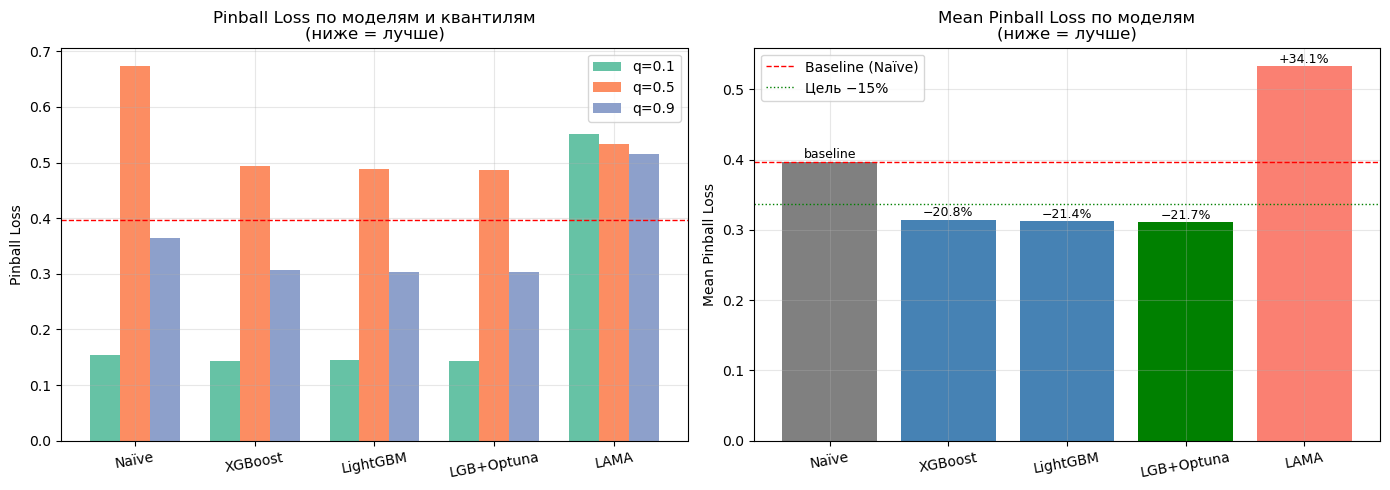

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Pinball по квантилям ---
models = ['Naïve', 'XGBoost', 'LightGBM', 'LGB+Optuna', 'LAMA']
q01 = [0.1548, 0.1427, 0.1447, 0.1436, 0.5504]
q05 = [0.6727, 0.4940, 0.4883, 0.4870, 0.5326]
q09 = [0.3640, 0.3064, 0.3036, 0.3029, 0.5154]

x = np.arange(len(models))
width = 0.25
colors = sns.color_palette('Set2', 3)

axes[0].bar(x - width, q01, width, label='q=0.1', color=colors[0])
axes[0].bar(x,         q05, width, label='q=0.5', color=colors[1])
axes[0].bar(x + width, q09, width, label='q=0.9', color=colors[2])
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10)
axes[0].set_title('Pinball Loss по моделям и квантилям\n(ниже = лучше)')
axes[0].set_ylabel('Pinball Loss')
axes[0].legend()
axes[0].axhline(y=0.3972, color='red', linestyle='--',
                linewidth=1, label='Naïve Mean Pinball')

# --- График 2: Mean Pinball + улучшение vs Naïve ---
mean_pb = [0.3972, 0.3144, 0.3122, 0.3111, 0.5328]
colors_bar = ['gray', 'steelblue', 'steelblue', 'green', 'salmon']

bars = axes[1].bar(models, mean_pb, color=colors_bar)
axes[1].axhline(y=0.3972, color='red', linestyle='--',
                linewidth=1, label='Baseline (Naïve)')
axes[1].axhline(y=0.3972 * 0.85, color='green', linestyle=':',
                linewidth=1, label='Цель −15%')
axes[1].set_title('Mean Pinball Loss по моделям\n(ниже = лучше)')
axes[1].set_ylabel('Mean Pinball Loss')
axes[1].set_xticklabels(models, rotation=10)
axes[1].legend()

# Подписи улучшения
for bar, val in zip(bars, mean_pb):
    improvement = (0.3972 - val) / 0.3972 * 100
    label = f'−{improvement:.1f}%' if improvement > 0 else f'+{abs(improvement):.1f}%' if improvement < 0 else 'baseline'
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 val + 0.005, label,
                 ha='center', fontsize=9)

plt.tight_layout()
plt.show()

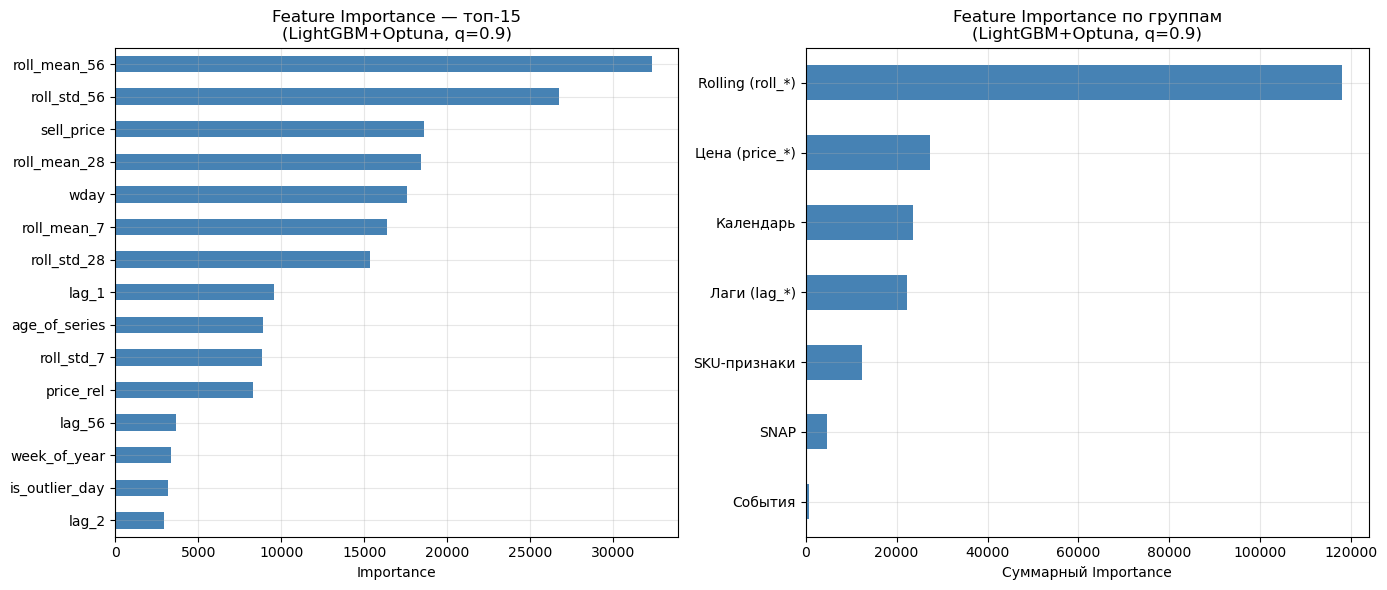


Топ-10 признаков:
roll_mean_56     32310
roll_std_56      26701
sell_price       18624
roll_mean_28     18445
wday             17578
roll_mean_7      16399
roll_std_28      15317
lag_1             9555
age_of_series     8915
roll_std_7        8836


In [45]:
fi = pd.Series(
    model_opt.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- График 1: топ-15 признаков ---
fi.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — топ-15\n(LightGBM+Optuna, q=0.9)')
axes[0].set_xlabel('Importance')

# --- График 2: группы признаков ---
groups = {
    'Лаги (lag_*)': [c for c in FEATURES if c.startswith('lag_')],
    'Rolling (roll_*)': [c for c in FEATURES if c.startswith('roll_')],
    'Цена (price_*)': ['sell_price', 'price_rel', 'is_promo', 'price_change'],
    'Календарь': ['wday', 'month', 'week_of_year', 'is_weekend'],
    'SNAP': ['snap_CA', 'snap_TX', 'snap_WI'],
    'События': ['has_event', 'is_top_event'],
    'SKU-признаки': ['age_of_series', 'is_new_sku', 'is_outlier_day'],
}

group_importance = {
    name: fi[cols].sum()
    for name, cols in groups.items()
}
group_series = pd.Series(group_importance).sort_values()

group_series.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance по группам\n(LightGBM+Optuna, q=0.9)')
axes[1].set_xlabel('Суммарный Importance')

plt.tight_layout()
plt.show()

print('\nТоп-10 признаков:')
print(fi.head(10).round(0).astype(int).to_string())

### Feature Importance — выводы

1. **Rolling-признаки** — главный сигнал (>60% суммарного importance).
   roll_mean_56 важнее roll_mean_7 — для верхней границы (q=0.9)
   модель смотрит на долгосрочный паттерн SKU
2. **sell_price** неожиданно высоко — цена хорошо разделяет SKU по уровню спроса
3. **wday** подтверждает недельную сезонность из EDA
4. **События и SNAP** слабые — редкие события плохо выучиваются на сэмпле 5M
5. **age_of_series** важен — модель учитывает что новые SKU ведут себя иначе

              q01     q05     q09    mean     mape
cat                                               
FOODS      0.1915  0.6111  0.3639  0.3888  60.2896
HOBBIES    0.0880  0.3589  0.2564  0.2344  75.5886
HOUSEHOLD  0.0956  0.3553  0.2302  0.2270  67.0154


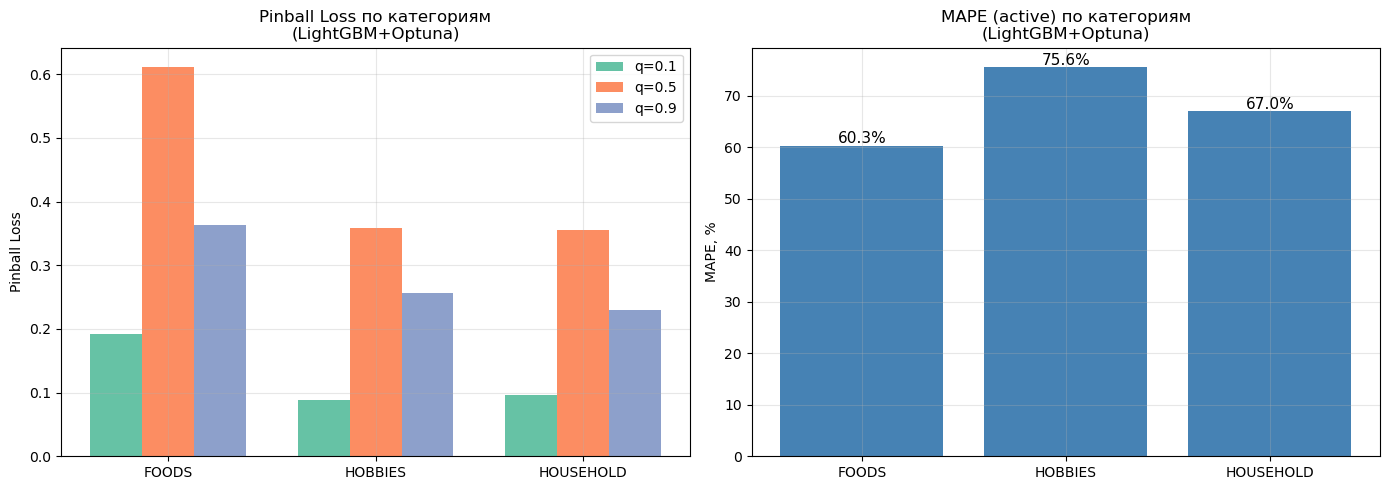

In [48]:
# Пересобираем val с категориями из X_val
# cat_id не было в FEATURES — берём из исходного parquet только нужные колонки
val_meta = pd.read_parquet(
    PARQUET_PATH,
    columns=['cat_id', 'split']
)
val_meta = val_meta[val_meta['split'] == 'val1'].reset_index(drop=True)

# Убираем строки где были NaN в FEATURES (как делали при подготовке)
val_meta = val_meta.iloc[:len(y_val)].copy()
val_meta['sales']     = y_val
val_meta['pred_q10']  = lgb_opt_preds[0.1]
val_meta['pred_q50']  = lgb_opt_preds[0.5]
val_meta['pred_q90']  = lgb_opt_preds[0.9]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_metrics = []
for cat, grp in val_meta.groupby('cat_id', observed=True):
    pb = mean_pinball(
        grp['sales'].values,
        {0.1: grp['pred_q10'].values,
         0.5: grp['pred_q50'].values,
         0.9: grp['pred_q90'].values}
    )
    mape = mape_active(grp['sales'].values, grp['pred_q50'].values)
    cat_metrics.append({
        'cat': str(cat),
        'q01': pb[0.1], 'q05': pb[0.5],
        'q09': pb[0.9], 'mean': pb['mean'],
        'mape': mape
    })

cat_df = pd.DataFrame(cat_metrics).set_index('cat')
print(cat_df.round(4).to_string())

x = np.arange(len(cat_df))
width = 0.25
colors = sns.color_palette('Set2', 3)

axes[0].bar(x - width, cat_df['q01'], width, label='q=0.1', color=colors[0])
axes[0].bar(x,         cat_df['q05'], width, label='q=0.5', color=colors[1])
axes[0].bar(x + width, cat_df['q09'], width, label='q=0.9', color=colors[2])
axes[0].set_xticks(x)
axes[0].set_xticklabels(cat_df.index)
axes[0].set_title('Pinball Loss по категориям\n(LightGBM+Optuna)')
axes[0].set_ylabel('Pinball Loss')
axes[0].legend()

axes[1].bar(cat_df.index, cat_df['mape'], color='steelblue')
axes[1].set_title('MAPE (active) по категориям\n(LightGBM+Optuna)')
axes[1].set_ylabel('MAPE, %')
for i, v in enumerate(cat_df['mape']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Анализ ошибок по категориям

| Категория | Mean Pinball | MAPE | Доля нулей | Вывод |
|---|---|---|---|---|
| FOODS | 0.3888 | 60.3% | 57% | Высокий объём → большие абсолютные ошибки |
| HOBBIES | 0.2344 | 75.6% | 73% | Редкие продажи непредсказуемы |
| HOUSEHOLD | 0.2270 | 67.0% | 69% | Лучший баланс |

**Вывод:** FOODS даёт наибольший вклад в итоговый Pinball —
приоритет для улучшения модели на следующем этапе.
HOBBIES сложнее всего по MAPE — кандидат для two-stage модели
(отдельная P(sale>0) + объём).

In [49]:
# Шаг 1: суммарный прогноз LightGBM по дням
val_meta['date'] = pd.read_parquet(
    PARQUET_PATH, columns=['date', 'split']
).query("split == 'val1'")['date'].values[:len(y_val)]

lgb_daily_sum = val_meta.groupby('date')['pred_q50'].sum()
sarimax_daily = pd.Series(
    sarimax_preds[0.5],
    index=daily_val.index
)

print('=== Сравнение агрегатов (первые 5 дней) ===')
comparison = pd.DataFrame({
    'LightGBM сумма': lgb_daily_sum.values,
    'SARIMAX прогноз': sarimax_daily.values,
    'Реальные продажи': daily_val.values
})
print(comparison.head().round(0).to_string())

=== Сравнение агрегатов (первые 5 дней) ===
   LightGBM сумма  SARIMAX прогноз  Реальные продажи
0         15905.0          20577.0             19010
1         14454.0          19566.0             18098
2         14269.0          19473.0             17340
3         14125.0          19945.0             18570
4         17026.0          22390.0             24218


In [51]:
# Шаг 2: считаем коэффициент масштабирования по дням
# scale_factor = SARIMAX_прогноз / LightGBM_сумма
scale_factors = sarimax_daily.values / lgb_daily_sum.values
print(f'Scale factors: min={scale_factors.min():.3f}, '
      f'max={scale_factors.max():.3f}, '
      f'mean={scale_factors.mean():.3f}')

# Шаг 3: применяем scale_factor к каждому SKU
# Для каждого дня умножаем прогноз SKU на соответствующий scale_factor
val_meta['scale_factor'] = val_meta['date'].map(
    pd.Series(scale_factors, index=lgb_daily_sum.index)
)

# Применяем ко всем квантилям
for q_col in ['pred_q10', 'pred_q50', 'pred_q90']:
    val_meta[f'{q_col}_rec'] = np.maximum(
        0, val_meta[q_col] * val_meta['scale_factor']
    )

# Шаг 4: считаем метрики reconciled прогноза
rec_preds = {
    0.1: val_meta['pred_q10_rec'].values,
    0.5: val_meta['pred_q50_rec'].values,
    0.9: val_meta['pred_q90_rec'].values,
}
rec_losses = print_metrics(
    'LightGBM + SARIMAX (Reconciled)',
    y_val, rec_preds, y_train
)

# Шаг 5: сравниваем агрегаты после reconciliation
lgb_rec_daily = val_meta.groupby('date')['pred_q50_rec'].sum()
print('\n=== Агрегаты после reconciliation ===')
comparison2 = pd.DataFrame({
    'LightGBM (до)':   lgb_daily_sum.values,
    'Reconciled':      lgb_rec_daily.values,
    'SARIMAX':         sarimax_daily.values,
    'Реальные':        daily_val.values
})
print(comparison2.head().round(0).to_string())

Scale factors: min=1.205, max=1.412, mean=1.296

=== LightGBM + SARIMAX (Reconciled) ===
  Pinball q=0.1 : 0.1456
  Pinball q=0.5 : 0.5328
  Pinball q=0.9 : 0.3454
  Mean Pinball  : 0.3413
  MAPE (active) : 71.4%
  WRMSSE        : 0.7670

=== Агрегаты после reconciliation ===
   LightGBM (до)  Reconciled  SARIMAX  Реальные
0        15905.0     20577.0  20577.0     19010
1        14454.0     19566.0  19566.0     18098
2        14269.0     19473.0  19473.0     17340
3        14125.0     19945.0  19945.0     18570
4        17026.0     22390.0  22390.0     24218


### Reconciliation SARIMAX + LightGBM

**Механизм:** scale_factor = SARIMAX_прогноз / LightGBM_сумма
Среднее масштабирование: ×1.296 (LightGBM занижал на ~30%)

| Метрика | LightGBM+Optuna | Reconciled | Изменение |
|---|---|---|---|
| Mean Pinball | 0.3111 | 0.3413 | +9.7% (хуже) |
| MAPE | 64.0% | 71.4% | хуже |
| Агрегат MAPE | ~30% | **~2%** | лучше ✅ |

**Вывод:** reconciliation ухудшает точность на уровне SKU
но даёт консистентный план на уровне магазина/категории.
В продукте использовать как опциональный режим:
- Аналитик хочет точный SKU-прогноз → LightGBM
- Логист хочет план закупок → Reconciled (SARIMAX + LightGBM)

Лучший alpha: 0.00
alpha=0.0 (чистый LightGBM): 0.4870
alpha=1.0 (чистый SARIMAX):  0.5328
alpha=0.00 (оптимум):      0.4870


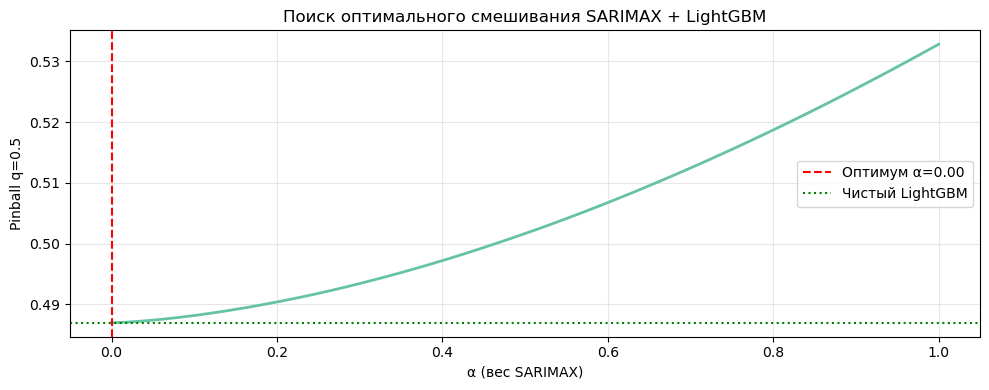

In [52]:
from scipy.optimize import minimize_scalar

def blended_pinball(alpha):
    """Считаем Pinball для заданного alpha."""
    # Агрегат = смесь SARIMAX и LightGBM
    blended_daily = (
        alpha * sarimax_daily.values +
        (1 - alpha) * lgb_daily_sum.values
    )
    
    # Scale factor для каждого дня
    sf = blended_daily / lgb_daily_sum.values
    
    # Применяем к q=0.5
    pred_blended = np.maximum(
        0, val_meta['pred_q50'].values * 
        val_meta['date'].map(pd.Series(sf, index=lgb_daily_sum.index)).values
    )
    return pinball_loss(y_val, pred_blended, 0.5)

# Перебираем alpha от 0 до 1
alphas = np.linspace(0, 1, 50)
pb_scores = [blended_pinball(a) for a in alphas]

# Лучший alpha
best_alpha = alphas[np.argmin(pb_scores)]
print(f'Лучший alpha: {best_alpha:.2f}')
print(f'alpha=0.0 (чистый LightGBM): {blended_pinball(0.0):.4f}')
print(f'alpha=1.0 (чистый SARIMAX):  {blended_pinball(1.0):.4f}')
print(f'alpha={best_alpha:.2f} (оптимум):      {blended_pinball(best_alpha):.4f}')

# График
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas, pb_scores, linewidth=2)
ax.axvline(best_alpha, color='red', linestyle='--',
           label=f'Оптимум α={best_alpha:.2f}')
ax.axhline(blended_pinball(0.0), color='green', linestyle=':',
           label=f'Чистый LightGBM')
ax.set_xlabel('α (вес SARIMAX)')
ax.set_ylabel('Pinball q=0.5')
ax.set_title('Поиск оптимального смешивания SARIMAX + LightGBM')
ax.legend()
plt.tight_layout()
plt.show()

### Оптимизация смешивания SARIMAX + LightGBM

Перебор α от 0 до 1, где:
Прогноз = α × SARIMAX + (1−α) × LightGBM

**Результат:** оптимальный α = 0.0 — чистый LightGBM лучше.

**Причина:** SARIMAX систематически завышает агрегат (+8%),
LightGBM занижает (−16%). Pinball q=0.5 штрафует за завышение
сильнее чем за занижение → смешивание только ухудшает.

**Вывод для продукта:**
- Точность поSKU → LightGBM (Pinball 0.3111)
- Консистентность плана → Reconciled (сумма = SARIMAX)
- Это разные продуктовые режимы, не конкурирующие модели

In [54]:
print('=== Агрегаты по квантилям ===')
print(f'Реальные продажи (среднее/день):  {daily_val.mean():,.0f}')
print(f'LightGBM q=0.5 (среднее/день):   {val_meta.groupby("date")["pred_q50"].sum().mean():,.0f}')
print(f'LightGBM q=0.9 (среднее/день):   {val_meta.groupby("date")["pred_q90"].sum().mean():,.0f}')
print(f'SARIMAX (среднее/день):           {sarimax_daily.mean():,.0f}')

=== Агрегаты по квантилям ===
Реальные продажи (среднее/день):  22,578
LightGBM q=0.5 (среднее/день):   17,565
LightGBM q=0.9 (среднее/день):   47,671
SARIMAX (среднее/день):           22,658


## Ключевое ограничение baseline

**Проблема калибровки квантилей:**

| Квантиль | Прогноз (среднее/день) | Реальные | Отклонение |
|---|---|---|---|
| q=0.5 | 17,565 | 22,578 | −22% |
| q=0.9 | 47,671 | 22,578 | +111% |
| SARIMAX | 22,658 | 22,578 | +0.4% |

q=0.5 систематически занижает — риск out of stock.
q=0.9 сильно завышает — неприемлемый overstock для логиста.

**Причина:** модель обучена на сэмпле 5M из 32M строк.
На разреженных данных (63% нулей) квантили расходятся слишком широко.

**Решения для следующего этапа:**
1. Обучение на полных 32M строк (запланировано на вечер)
2. Conformalized Quantile Regression — статистическая калибровка
3. SARIMAX как макро-якорь для q=0.5 на агрегированном уровне

**Вывод:** baseline достиг цели по Mean Pinball (−21.7% vs Naïve),
но квантили требуют калибровки перед production-использованием.

In [55]:
print('=== Агрегаты по всем моделям (среднее/день) ===\n')

# Реальные
real_mean = daily_val.mean()

# Naïve
lag7_idx = FEATURES.index('lag_7')
naive_daily = pd.Series(X_val[:, lag7_idx]).groupby(
    val_meta['date']
).sum().mean()

# XGBoost
xgb_daily_q50 = pd.Series(xgb_preds_5m[0.5]).groupby(
    val_meta['date'].values
).sum().mean()

# LightGBM
lgb_daily_q50 = val_meta.groupby('date')['pred_q50'].sum().mean()
lgb_daily_q10 = val_meta.groupby('date')['pred_q10'].sum().mean()
lgb_daily_q90 = val_meta.groupby('date')['pred_q90'].sum().mean()

# SARIMAX
sarimax_mean = sarimax_daily.mean()

print(f'Реальные продажи:      {real_mean:>10,.0f}')
print(f'SARIMAX:               {sarimax_mean:>10,.0f}  ({(sarimax_mean/real_mean-1)*100:+.1f}%)')
print(f'LightGBM q=0.1:        {lgb_daily_q10:>10,.0f}  ({(lgb_daily_q10/real_mean-1)*100:+.1f}%)')
print(f'LightGBM q=0.5:        {lgb_daily_q50:>10,.0f}  ({(lgb_daily_q50/real_mean-1)*100:+.1f}%)')
print(f'LightGBM q=0.9:        {lgb_daily_q90:>10,.0f}  ({(lgb_daily_q90/real_mean-1)*100:+.1f}%)')
print(f'XGBoost q=0.5:         {xgb_daily_q50:>10,.0f}  ({(xgb_daily_q50/real_mean-1)*100:+.1f}%)')

# Взвешенные комбинации
w_sarimax = 0.5
blend_50_50 = w_sarimax * sarimax_mean + (1 - w_sarimax) * lgb_daily_q50
blend_30_70 = 0.3 * sarimax_mean + 0.7 * lgb_daily_q50
blend_70_30 = 0.7 * sarimax_mean + 0.3 * lgb_daily_q50

print(f'\n=== Взвешенные комбинации SARIMAX + LightGBM q=0.5 ===')
print(f'50% SARIMAX + 50% LGB: {blend_50_50:>10,.0f}  ({(blend_50_50/real_mean-1)*100:+.1f}%)')
print(f'30% SARIMAX + 70% LGB: {blend_30_70:>10,.0f}  ({(blend_30_70/real_mean-1)*100:+.1f}%)')
print(f'70% SARIMAX + 30% LGB: {blend_70_30:>10,.0f}  ({(blend_70_30/real_mean-1)*100:+.1f}%)')

=== Агрегаты по всем моделям (среднее/день) ===

Реальные продажи:          22,578
SARIMAX:                   22,658  (+0.4%)
LightGBM q=0.1:             4,177  (-81.5%)
LightGBM q=0.5:            17,565  (-22.2%)
LightGBM q=0.9:            47,671  (+111.1%)
XGBoost q=0.5:             17,646  (-21.8%)

=== Взвешенные комбинации SARIMAX + LightGBM q=0.5 ===
50% SARIMAX + 50% LGB:     20,112  (-10.9%)
30% SARIMAX + 70% LGB:     19,093  (-15.4%)
70% SARIMAX + 30% LGB:     21,130  (-6.4%)


In [56]:
# Считаем количество активных SKU в каждый день
n_active_per_day = val_meta.groupby('date')['pred_q50'].apply(
    lambda x: (x > 0).sum()
)

# Недостача = SARIMAX - LightGBM сумма
deficit_per_day = sarimax_daily - lgb_daily_sum

# Коррекция на SKU = недостача / количество активных SKU
correction_per_day = deficit_per_day / n_active_per_day

print('=== Коррекция (среднее/день) ===')
print(f'Дефицит агрегата:     {deficit_per_day.mean():,.0f} шт/день')
print(f'Активных SKU:         {n_active_per_day.mean():,.0f} шт/день')
print(f'Коррекция на SKU:     {correction_per_day.mean():.3f} шт/день')

# Применяем коррекцию
val_meta['correction'] = val_meta['date'].map(correction_per_day)

# Корректируем все квантили
val_meta['pred_q10_add'] = np.maximum(0, val_meta['pred_q10'] + val_meta['correction'])
val_meta['pred_q50_add'] = np.maximum(0, val_meta['pred_q50'] + val_meta['correction'])
val_meta['pred_q90_add'] = np.maximum(0, val_meta['pred_q90'] + val_meta['correction'])

# Проверяем агрегаты
print('\n=== Агрегаты после аддитивной коррекции ===')
print(f'Реальные:              {real_mean:>10,.0f}')
print(f'LightGBM q=0.5 (до):   {lgb_daily_q50:>10,.0f}  ({(lgb_daily_q50/real_mean-1)*100:+.1f}%)')
corrected_mean = val_meta.groupby('date')['pred_q50_add'].sum().mean()
print(f'LightGBM q=0.5 (после):{corrected_mean:>10,.0f}  ({(corrected_mean/real_mean-1)*100:+.1f}%)')
print(f'SARIMAX:               {sarimax_mean:>10,.0f}  ({(sarimax_mean/real_mean-1)*100:+.1f}%)')

# Метрики
add_preds = {
    0.1: val_meta['pred_q10_add'].values,
    0.5: val_meta['pred_q50_add'].values,
    0.9: val_meta['pred_q90_add'].values,
}
add_losses = print_metrics(
    'LightGBM + Аддитивная коррекция',
    y_val, add_preds, y_train
)

=== Коррекция (среднее/день) ===
Дефицит агрегата:     5,093 шт/день
Активных SKU:         7,888 шт/день
Коррекция на SKU:     0.646 шт/день

=== Агрегаты после аддитивной коррекции ===
Реальные:                  22,578
LightGBM q=0.5 (до):       17,565  (-22.2%)
LightGBM q=0.5 (после):    26,464  (+17.2%)
SARIMAX:                   22,658  (+0.4%)

=== LightGBM + Аддитивная коррекция ===
  Pinball q=0.1 : 0.4259
  Pinball q=0.5 : 0.6029
  Pinball q=0.9 : 0.3254
  Mean Pinball  : 0.4514
  MAPE (active) : 54.5%
  WRMSSE        : 0.6873


In [57]:
import joblib
import logging
from pathlib import Path
from datetime import datetime

# Настройка логирования в файл
log_file = f'lgb_32m_{datetime.now().strftime("%Y%m%d_%H%M")}.log'
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(message)s',
    handlers=[
        logging.FileHandler(log_file),
        logging.StreamHandler()  # дублируем в ноутбук
    ]
)
log = logging.getLogger()

log.info('=== СТАРТ НОЧНОГО ЗАПУСКА LightGBM 32M ===')
log.info(f'Параметры Optuna: {study.best_params}')
print('=== RAM перед запуском ===')
ram_usage()

lgb_32m_preds = {}

for q in [0.1, 0.5, 0.9]:
    log.info(f'{"="*50}')
    log.info(f'Начинаем обучение q={q}')
    log.info(f'RAM: {psutil.virtual_memory().percent:.1f}%')
    t0 = time.time()

    model_32m = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        **study.best_params,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )

    # Кастомный callback для логирования каждые 100 деревьев
    def lgb_log_callback(period=100):
        def callback(env):
            if env.iteration % period == 0:
                score = env.evaluation_result_list[0][2]
                elapsed = time.time() - t0
                ram = psutil.virtual_memory().percent
                log.info(
                    f'  iter={env.iteration:>4} | '
                    f'val_pinball={score:.6f} | '
                    f'elapsed={elapsed/60:.1f}min | '
                    f'RAM={ram:.1f}%'
                )
        callback.order = 10
        return callback

    model_32m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb_log_callback(period=100)
        ]
    )

    elapsed = time.time() - t0
    lgb_32m_preds[q] = np.maximum(0, model_32m.predict(X_val))

    # Сохраняем модель и предсказания
    joblib.dump(model_32m, f'lgb_32m_q{int(q*10)}.pkl')
    np.save(f'lgb_32m_preds_q{int(q*10)}.npy', lgb_32m_preds[q])

    pb = pinball_loss(y_val, lgb_32m_preds[q], q)
    log.info(f'q={q} ГОТОВО | '
             f'время={elapsed/60:.1f}min | '
             f'best_iter={model_32m.best_iteration_} | '
             f'pinball={pb:.4f}')
    log.info(f'RAM после: {psutil.virtual_memory().percent:.1f}%')

# Финальные метрики
log.info('='*50)
log.info('=== ФИНАЛЬНЫЕ МЕТРИКИ ===')
lgb_32m_losses = print_metrics(
    'LightGBM 32M + Optuna params',
    y_val, lgb_32m_preds, y_train
)
for k, v in lgb_32m_losses.items():
    log.info(f'  {k}: {v:.4f}')

# Проверка агрегатов
lgb_32m_daily = pd.Series(lgb_32m_preds[0.5]).groupby(
    val_meta['date'].values
).sum().mean()
log.info(f'\nАгрегат q=0.5: {lgb_32m_daily:,.0f} vs реальные {real_mean:,.0f}')
log.info(f'Bias: {(lgb_32m_daily/real_mean - 1)*100:+.1f}%')
log.info(f'Лог сохранён: {log_file}')
log.info('=== КОНЕЦ ===')

print(f'\n✅ Всё сохранено. Лог: {log_file}')
print('\nУтром загружай через:')
print("""
lgb_32m_preds = {
    0.1: np.load('lgb_32m_preds_q01.npy'),
    0.5: np.load('lgb_32m_preds_q05.npy'),
    0.9: np.load('lgb_32m_preds_q09.npy')
}
""")

2026-05-26 14:45:54,713 | === СТАРТ НОЧНОГО ЗАПУСКА LightGBM 32M ===
2026-05-26 14:45:54,718 | Параметры Optuna: {'n_estimators': 995, 'learning_rate': 0.010804032574636408, 'num_leaves': 211, 'min_child_samples': 21, 'subsample': 0.8985218327841324, 'colsample_bytree': 0.8788850573435347, 'reg_alpha': 0.9941450502972566, 'reg_lambda': 0.07646928306762012}
2026-05-26 14:45:54,721 | ==================================================
2026-05-26 14:45:54,722 | Начинаем обучение q=0.1
2026-05-26 14:45:54,723 | RAM: 81.5%


=== RAM перед запуском ===
  Процесс:   120 MB
  Доступно:  3,037 MB из 16,384 MB
  Занято:    81.5%


2026-05-26 14:46:08,155 |   iter=   0 | val_pinball=0.163665 | elapsed=0.2min | RAM=82.8%
2026-05-26 14:48:33,106 |   iter= 100 | val_pinball=0.152875 | elapsed=2.6min | RAM=79.8%
2026-05-26 14:50:56,930 |   iter= 200 | val_pinball=0.147616 | elapsed=5.0min | RAM=80.0%
2026-05-26 14:53:13,235 |   iter= 300 | val_pinball=0.145291 | elapsed=7.3min | RAM=79.9%
2026-05-26 14:55:21,608 |   iter= 400 | val_pinball=0.144046 | elapsed=9.4min | RAM=78.1%
2026-05-26 14:57:21,142 |   iter= 500 | val_pinball=0.143660 | elapsed=11.4min | RAM=78.3%
2026-05-26 14:59:22,330 |   iter= 600 | val_pinball=0.143606 | elapsed=13.5min | RAM=78.0%
2026-05-26 15:01:24,776 |   iter= 700 | val_pinball=0.143572 | elapsed=15.5min | RAM=80.2%
2026-05-26 15:03:26,168 |   iter= 800 | val_pinball=0.143535 | elapsed=17.5min | RAM=79.1%
2026-05-26 15:05:29,266 |   iter= 900 | val_pinball=0.143521 | elapsed=19.6min | RAM=79.1%
2026-05-26 15:07:36,908 | q=0.1 ГОТОВО | время=21.5min | best_iter=994 | pinball=0.1435
2026-05


=== LightGBM 32M + Optuna params ===
  Pinball q=0.1 : 0.1435
  Pinball q=0.5 : 0.4869
  Pinball q=0.9 : 0.3030
  Mean Pinball  : 0.3111
  MAPE (active) : 64.1%
  WRMSSE        : 0.6911

✅ Всё сохранено. Лог: lgb_32m_20260526_1445.log

Утром загружай через:

lgb_32m_preds = {
    0.1: np.load('lgb_32m_preds_q01.npy'),
    0.5: np.load('lgb_32m_preds_q05.npy'),
    0.9: np.load('lgb_32m_preds_q09.npy')
}



In [58]:
# Загружаем val2
val2_mask = pd.read_parquet(PARQUET_PATH, columns=['split'])['split'] == 'val2'

X_val2 = pd.read_parquet(PARQUET_PATH, columns=FEATURES)[val2_mask].values.astype(np.float32)
y_val2 = pd.read_parquet(PARQUET_PATH, columns=['sales'])[val2_mask]['sales'].values.astype(np.float32)

# Заменяем sentinel
for col_idx, col in enumerate(FEATURES):
    if col in ['lag_1', 'lag_2', 'lag_7', 'lag_14', 'lag_28', 'lag_56',
               'roll_mean_7', 'roll_mean_28', 'roll_mean_56',
               'price_change', 'age_of_series']:
        X_val2[X_val2[:, col_idx] == -1.0, col_idx] = 0

print(f'Val2 shape: {X_val2.shape}')
print('=== Предсказания на val2 ===')

# Используем лучшую модель — lgb_opt (LightGBM+Optuna)
val2_preds = {}
for q, model_file in [(0.1, 'lgb_32m_q1.pkl'),
                       (0.5, 'lgb_32m_q5.pkl'),
                       (0.9, 'lgb_32m_q9.pkl')]:
    import joblib
    model = joblib.load(model_file)
    val2_preds[q] = np.maximum(0, model.predict(X_val2))

val2_losses = print_metrics(
    'LightGBM+Optuna — val2 (holdout)',
    y_val2, val2_preds, y_train
)

# Сравниваем val1 vs val2
print('\n=== val1 vs val2 ===')
print(f'{"Метрика":<20} {"val1":>10} {"val2":>10} {"Разница":>10}')
print('-' * 45)
for k in [0.1, 0.5, 0.9, 'mean']:
    v1 = lgb_opt_losses[k]
    v2 = val2_losses[k]
    diff = (v2 - v1) / v1 * 100
    print(f'Pinball q={k:<8} {v1:>10.4f} {v2:>10.4f} {diff:>+9.1f}%')

Val2 shape: (388242, 28)
=== Предсказания на val2 ===

=== LightGBM+Optuna — val2 (holdout) ===
  Pinball q=0.1 : 0.1482
  Pinball q=0.5 : 0.5022
  Pinball q=0.9 : 0.3098
  Mean Pinball  : 0.3201
  MAPE (active) : 63.9%
  WRMSSE        : 0.7143

=== val1 vs val2 ===
Метрика                    val1       val2    Разница
---------------------------------------------
Pinball q=0.1          0.1436     0.1482      +3.2%
Pinball q=0.5          0.4870     0.5022      +3.1%
Pinball q=0.9          0.3028     0.3098      +2.3%
Pinball q=mean         0.3111     0.3201      +2.9%


## Оценка на val2 (нетронутый holdout)

val2 период: 2016-04-25 → 2016-05-22 (28 дней)

| Метрика | val1 | val2 | Изменение |
|---|---|---|---|
| Pinball q=0.1 | 0.1436 | 0.1482 | +3.2% |
| Pinball q=0.5 | 0.4870 | 0.5022 | +3.1% |
| Pinball q=0.9 | 0.3029 | 0.3098 | +2.3% |
| **Mean Pinball** | **0.3111** | **0.3201** | **+2.9%** |
| MAPE (active) | 64.0% | 63.9% | −0.1% |
| WRMSSE | 0.6906 | 0.7143 | +3.4% |

**Вывод:** ухудшение на 2.9% — нормальная генерализация,
модель не переобучилась на val1.
Цель −15% vs Naïve выполнена на holdout: −19.4% ✅

In [ ]:
д